<a href="https://colab.research.google.com/github/tivanello/fase2/blob/main/notebooks/TECH_CHALLENGE_FASE_02_Eduardo_Gil_Tivanello_ENTREGA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Você foi recentemente alocado em uma equipe de cientistas de dados de um grande fundo de investimentos brasileiro. Sua missão inicial é desenvolver um modelo preditivo capaz de prever se o índice IBOVESPA vai fechar em alta ou baixa no dia seguinte, com base em dados históricos do próprio índice. Esse modelo será usado como insumo para alimentar dashboards internos de tomada de decisão dos analistas quantitativos da empresa.
# Dados
Utilize os dados históricos do índice IBOVESPA, disponíveis publicamente: https://br.investing.com/indices/bovespa-historical-data

# Requisitos:
• Selecione o período “diário”.
• Baixe um intervalo de pelo menos 2 anos de dados.
• Realize o pré-processamento necessário para utilizar os dados no
modelo.

# Objetivo
Criar um modelo que preveja se o fechamento do IBOVESPA do dia seguinte será maior ou menor que o do dia atual, ou seja: Seu modelo deve prever a tendência (↑ ou ↓) com acuracidade mínima de 75% em um conjunto de teste. O conjunto de testes deverá conter o último mês (30 dias) de dados disponíveis.

# Entregas Esperadas
Você deverá apresentar ao time de investimentos:
Storytelling Técnico
Apresentação com os seguintes requisitos:
• Aquisição e exploração dos dados;
• Estratégia de engenharia de atributos, caso seja realizado (por exemplo: variações, médias móveis, etc)
• Preparação da base para previsão (definição de target, janela de tempo, etc.);
• Escolha e justificativa do modelo utilizado;
• Resultados e análise de métricas que garantem que o modelo está confiável;

# Justificativa Técnica
Explique claramente:
• Por que você escolheu o(s) modelo(s) utilizados (ex: árvores, regressão logística, LSTM, etc.);
• Como tratou a natureza sequencial dos dados (ex: janelas deslizantes, features lagged);
• Quais os trade-offs entre acuracidade e overfitting.

#Quais documentos devo subir na plataforma? As entregas deverão conter necessariamente:
• Uma pasta zip contendo todos os arquivos do projeto, ou um link para o repositório do GitHub com seu projeto.
• Apresentação do storytelling. Pode ser em PPT, PDF ou ferramentas da sua preferência, como o CANVAS, por exemplo.
• Vídeo de no máximo 5 (cinco) minutos, com uma visão gerencial, explicando como interpretar os resultados obtidos. Note que é necessário que todos os membros do grupo apareçam no vídeo.

**Dica: Utilize o maior intervalo de tempo possível para atingir maior  acuracidade no modelo preditivo.**

Lembre-se que você poderá apresentar o desenvolvimento do seu projeto durante as lives e grupos de estudo com os(as) docentes. Essas são ótimas oportunidades para discutir sobre as dificuldades encontradas, além de pegar dicas valiosas com especialistas e colegas de turma. Não se esqueça que isso é um entregável obrigatório! Se atente para o prazo de entrega até o final da fase.

**Importação dos arquivos.**

 tentei importar toda a série histórica, à partir de 01/08/1994,  porém o arquivo vinha apenas até 10/10/2014. Como solução realizei a importação de  dois arquivos e realizada junção dos dois nas linhas de comando abaixo. Iremos trabalhar com o arquivo com a série hitórica de 01/08/1994 até 01/08/2025

In [1]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/tivanello/fase2/main/data/raw/Dados%20Hist%C3%B3ricos%20-%20Ibovespa%2011-10-2014%2016-09-2025.csv"
url2 = "https://raw.githubusercontent.com/tivanello/fase2/main/data/raw/Dados%20Hist%C3%B3ricos%20-%20Ibovespa%201994%2010-10-2014.csv"

df1 = pd.read_csv(url1, thousands='.', decimal=',')
df2 = pd.read_csv(url2, thousands='.', decimal=',')

df_ibovespa = pd.concat([df1, df2], ignore_index=True)

print(df_ibovespa.head())
print(df_ibovespa.shape)






       Data  Último  Abertura  Máxima  Mínima   Vol.    Var%
0  16092025  144062    143547  144584  143547  8,48B   0,36%
1  15092025  143547    142292  144194  142292  6,61B   0,90%
2  12092025  142272    143151  143202  142241  6,39B  -0,61%
3  11092025  143151    142349  144013  142349  7,57B   0,56%
4  10092025  142349    141612  143182  141612  7,14B   0,52%
(7711, 7)


In [2]:
# Visualização das primeiras linhas
df_ibovespa.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,16092025,144062,143547,144584,143547,"8,48B","0,36%"
1,15092025,143547,142292,144194,142292,"6,61B","0,90%"
2,12092025,142272,143151,143202,142241,"6,39B","-0,61%"
3,11092025,143151,142349,144013,142349,"7,57B","0,56%"
4,10092025,142349,141612,143182,141612,"7,14B","0,52%"


Preciso ajustar o nome das colunas retirando o maiusculo e acentuação e abreviações (Vol. para volume e Var% para variacao). Será necessário instalar a biblioteca unicode ( biblioteca Python que remove acentos e caracteres especiais, convertendo textos para versões ASCII simples)


In [3]:

!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.6 MB/s eta 0:00:00


In [4]:
import unidecode

# Renomeia colunas: remove acentos e converte para minúsculas
df_ibovespa.columns = [unidecode.unidecode(col).lower().replace('vol.', 'volume').replace('var%', 'variacao') for col in df_ibovespa.columns]

# Visualiza o novo nome das colunas
print(df_ibovespa.columns)

Index(['data', 'ultimo', 'abertura', 'maxima', 'minima', 'volume', 'variacao'], dtype='object')


In [5]:
df_ibovespa.head()

,data,ultimo,abertura,maxima,minima,volume,variacao
0,16092025,144062,143547,144584,143547,"8,48B","0,36%"
1,15092025,143547,142292,144194,142292,"6,61B","0,90%"
2,12092025,142272,143151,143202,142241,"6,39B","-0,61%"
3,11092025,143151,142349,144013,142349,"7,57B","0,56%"
4,10092025,142349,141612,143182,141612,"7,14B","0,52%"


Ajuste da Data: Analisando o arquivo notei que a data não esta no formato correto, sendo necessária a sua formação


In [6]:
df_ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7711 entries, 0 to 7710
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   data      7711 non-null   int64 
 1   ultimo    7711 non-null   int64 
 2   abertura  7711 non-null   int64 
 3   maxima    7711 non-null   int64 
 4   minima    7711 non-null   int64 
 5   volume    7710 non-null   object
 6   variacao  7711 non-null   object
dtypes: int64(5), object(2)
memory usage: 421.8+ KB


In [7]:
# Verifica se há avlores Nulos

df_ibovespa[df_ibovespa["volume"].isnull()]

,data,ultimo,abertura,maxima,minima,volume,variacao
2386,10022016,40377,40592,40592,39960,NaN,"-0,53%"


In [8]:
# Corrige a coluna 'data' para string de 8 dígitos (DDMMYYYY)

df_ibovespa['data'] = df_ibovespa['data'].astype(str).str.zfill(8)
df_ibovespa['data'] = pd.to_datetime(df_ibovespa['data'], format='%d%m%Y')

# Ordena por data
df_ibovespa = df_ibovespa.sort_values(by='data').reset_index(drop=True)



In [9]:
# 2) Converter variacao (texto) -> número
df_ibovespa["variacao_num"] = (
    df_ibovespa["variacao"].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float) / 100.0
)




In [10]:
# função para converter o dados da coluna volume em valor
def converter_volume(valor):
    if isinstance(valor, str):
        valor = valor.replace(',', '.').strip()
        if valor.endswith('K'):
            return float(valor.replace('K', '')) * 1e3
        elif valor.endswith('M'):
            return float(valor.replace('M', '')) * 1e6
        elif valor.endswith('B'):
            return float(valor.replace('B', '')) * 1e9
        else:
            return float(valor)
    return valor  # já numérico

# Aplicar a função
df_ibovespa['volume'] = df_ibovespa['volume'].apply(converter_volume)

# Preencher valores ausentes com o valor da linha anterior
df_ibovespa['volume'] = df_ibovespa['volume'].fillna(method='ffill')


/tmp/ipykernel_3090/3680603689.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ibovespa['volume'] = df_ibovespa['volume'].fillna(method='ffill')


In [11]:
#Converter colunas para float64
colunas_float = ['ultimo', 'abertura', 'maxima', 'minima']
df_ibovespa[colunas_float] = df_ibovespa[colunas_float].astype(float)

In [12]:
# Garantir ordem e unicidade por data (evita target quebrado por duplicidade)
df_ibovespa["data"] = pd.to_datetime(df_ibovespa["data"], errors="coerce", dayfirst=True)

df_ibovespa = (
    df_ibovespa
    .dropna(subset=["data"])
    .sort_values("data")
    .drop_duplicates(subset=["data"], keep="last")
    .reset_index(drop=True)
)

print("Linhas:", len(df_ibovespa))
print("Datas duplicadas:", df_ibovespa["data"].duplicated().sum())
print("Data min/max:", df_ibovespa["data"].min(), df_ibovespa["data"].max())


Linhas: 7711
Datas duplicadas: 0
Data min/max: 1994-08-01 00:00:00 2025-09-16 00:00:00


In [13]:
df_ibovespa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7711 entries, 0 to 7710
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          7711 non-null   datetime64[ns]
 1   ultimo        7711 non-null   float64       
 2   abertura      7711 non-null   float64       
 3   maxima        7711 non-null   float64       
 4   minima        7711 non-null   float64       
 5   volume        7711 non-null   float64       
 6   variacao      7711 non-null   object        
 7   variacao_num  7711 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 482.1+ KB


In [14]:
df_ibovespa.tail()

,data,ultimo,abertura,maxima,minima,volume,variacao,variacao_num
7706,2025-09-10,142349.0,141612.0,143182.0,141612.0,7.140000e+09,"0,52%",0.0052
7707,2025-09-11,143151.0,142349.0,144013.0,142349.0,7.570000e+09,"0,56%",0.0056
7708,2025-09-12,142272.0,143151.0,143202.0,142241.0,6.390000e+09,"-0,61%",-0.0061
7709,2025-09-15,143547.0,142292.0,144194.0,142292.0,6.610000e+09,"0,90%",0.0090
7710,2025-09-16,144062.0,143547.0,144584.0,143547.0,8.480000e+09,"0,36%",0.0036


In [15]:
df_ibovespa.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,variacao_num
0,1994-08-01,4152.0,4201.0,4223.0,4091.0,5.390000e+09,"-1,17%",-0.0117
1,1994-08-02,4311.0,4152.0,4311.0,4152.0,6.630000e+09,"3,83%",0.0383
2,1994-08-03,4392.0,4311.0,4426.0,4275.0,6.880000e+09,"1,88%",0.0188
3,1994-08-04,4355.0,4392.0,4406.0,4321.0,5.670000e+09,"-0,84%",-0.0084
4,1994-08-05,4470.0,4355.0,4476.0,4329.0,5.140000e+09,"2,64%",0.0264


In [16]:
df_ibovespa.isnull().sum()

,0
data,0
ultimo,0
abertura,0
maxima,0
minima,0
volume,0
variacao,0
variacao_num,0


Necessidade de criar a minha variável de tendência, onde:

1 = O fechamento do IBOVESPA no dia seguinte será maior que o de hoje (alta)

0 = O fechamento do IBOVESPA no dia seguinte será igual ou menor que o de hoje (sem alta)

In [17]:
# Criao meu target - Tendência

import numpy as np

# Criar a variável target com base no fechamento (ultimo)
prox = df_ibovespa["ultimo"].shift(-1)

df_ibovespa["tendencia"] = np.where(
    prox.notna(),
    (prox > df_ibovespa["ultimo"]).astype(int),
    np.nan
)

# Remover a última linha (que fica sem target válido)
df_ibovespa = df_ibovespa.dropna(subset=["tendencia"]).copy()
df_ibovespa["tendencia"] = df_ibovespa["tendencia"].astype(int)





In [18]:
df_ibovespa.tail()

,data,ultimo,abertura,maxima,minima,volume,variacao,variacao_num,tendencia
7705,2025-09-09,141618.0,141794.0,142286.0,141605.0,7.480000e+09,"-0,12%",-0.0012,1
7706,2025-09-10,142349.0,141612.0,143182.0,141612.0,7.140000e+09,"0,52%",0.0052,1
7707,2025-09-11,143151.0,142349.0,144013.0,142349.0,7.570000e+09,"0,56%",0.0056,0
7708,2025-09-12,142272.0,143151.0,143202.0,142241.0,6.390000e+09,"-0,61%",-0.0061,1
7709,2025-09-15,143547.0,142292.0,144194.0,142292.0,6.610000e+09,"0,90%",0.0090,1


## Estratégia de Engenharia de Atributos (Features) — IBOVESPA

A ideia das features abaixo é transformar o “preço puro” (**ultimo**) em sinais de **tendência, força do movimento, risco/instabilidade, padrão de candle, volume e sazonalidade**.  
Todas as variáveis foram construídas **usando apenas informações do passado (até o dia t)**, sem olhar o futuro.

---

**1) Retornos (variação percentual do preço)**  
Medem quanto o preço mudou em janelas curtas. São bons para capturar **momento**.

- **retorno_1d**: variação percentual de 1 dia (**pct_change(1)**). Representa o comportamento **de ontem para hoje**.
- **retorno_3d**: variação percentual acumulada em 3 dias (**pct_change(3)**). Representa tendência de **curtíssimo prazo**.
- **retorno_7d**: variação percentual acumulada em 7 dias (**pct_change(7)**). Representa sinal de tendência **semanal**.

---

**2) Médias móveis (suavização do preço)**  
Servem para reduzir ruído do preço diário e enxergar a direção geral em janelas curtas.

- **media_movel_3**: média do fechamento (**ultimo**) dos últimos **3 pregões** (**rolling(window=3).mean()**). Suaviza ruídos de curtíssimo prazo.
- **media_movel_7**: média do fechamento (**ultimo**) dos últimos **7 pregões** (**rolling(window=7).mean()**). Mostra direção geral da semana (tendência curta).

---

**3) Volatilidade (instabilidade / risco)**  
Volatilidade aqui é o **desvio padrão** do fechamento em janelas curtas: quanto mais alto, mais instável.

- **volatilidade_3d**: desvio padrão do fechamento (**ultimo**) nos últimos **3 pregões** (**rolling(window=3).std()**). Mede instabilidade **muito recente**.
- **volatilidade_7d**: desvio padrão do fechamento (**ultimo**) nos últimos **7 pregões** (**rolling(window=7).std()**). Mede instabilidade **semanal**.

---

**4) RSI (Relative Strength Index) — força do movimento**  
Mede a velocidade/força do movimento recente (0 a 100). Ajuda a captar **sobrecompra/sobrevenda**.

- **rsi_14**: RSI com janela de **14 dias** (**RSIIndicator(close=ultimo, window=14).rsi()**). Em geral:  
  - RSI > 70 sugere **sobrecompra** (pode perder força / possível reversão)  
  - RSI < 30 sugere **sobrevenda** (pode reagir / possível reversão)

---

**5) MACD (12-26-9) — tendência por médias exponenciais**  
Indicador de tendência baseado na diferença entre médias móveis exponenciais. Ajuda a identificar **mudança de direção**.

- **macd**: linha principal do MACD (**EMA12 − EMA26**). Positivo costuma indicar tendência de **alta**; negativo, **baixa**.
- **macd_signal**: linha de sinal (**EMA9 do macd**). Cruzamentos com **macd** indicam possíveis mudanças de tendência.
- **macd_diff**: histograma (**macd − macd_signal**). Mostra a **força** do sinal: quanto maior o valor absoluto, maior a “convicção”.

---

**6) Distância do preço para as médias (tendência relativa)**  
Mostra se o preço está “esticado” para cima/baixo em relação à média. Útil para detectar **afastamento** e possíveis correções.

- **dist_mm_3**: distância percentual do preço para a média móvel de 3 dias (**(ultimo / media_movel_3) - 1**).  
  > 0: preço acima da média; < 0: abaixo.
- **dist_mm_7**: distância percentual do preço para a média móvel de 7 dias (**(ultimo / media_movel_7) - 1**).  
  Mesma lógica, mas em janela semanal.
- **cruz_mm_3_7**: relação entre médias de 3 e 7 dias (**(media_movel_3 / media_movel_7) - 1**).  
  > 0: média curta acima da semanal (tendência mais positiva); < 0: o contrário.

---

**7) Candle features (padrão do pregão em % do preço)**  
Usam **abertura**, **maxima**, **minima** e **ultimo**. Representam a “forma” do candle e capturam pressão compradora/vendedora no dia.

- **amplitude_pct**: amplitude do dia normalizada (**(maxima - minima) / ultimo**). Mede o “tamanho do dia” (volatilidade intradiária).
- **corpo_pct**: tamanho do corpo do candle (**(ultimo - abertura) / abertura**).  
  > 0: fechou acima da abertura; < 0: fechou abaixo.
- **sombra_sup_pct**: sombra superior (**(maxima - max(abertura, ultimo)) / ultimo**). Indica rejeição no topo (tentou subir e voltou).
- **sombra_inf_pct**: sombra inferior (**(min(abertura, ultimo) - minima) / ultimo**). Indica rejeição no fundo (tentou cair e voltou).

---

**8) Volume features (força do movimento)**  
Volume ajuda a diferenciar movimentos “fracos” de movimentos com maior participação do mercado.

- **volume_ret_1d**: variação percentual do volume de ontem para hoje (**volume.pct_change(1)**).
- **volume_mm_7**: média móvel de 7 dias do volume (**volume.rolling(7).mean()**). Representa o “volume típico” da semana.

---

**9) Calendário (sazonalidade)**  
Captura padrões por dia da semana e mês que às vezes aparecem em séries financeiras.

- **dow**: dia da semana (**data.dt.dayofweek**), onde 0=segunda … 4=sexta.
- **month**: mês (**data.dt.month**), de 1 a 12.

---

**Limpeza final (dropna)**  
Após criar as features, algumas linhas iniciais ficam com **NaN** por causa de **pct_change(...)**, **rolling(...)** e indicadores (RSI/MACD), que precisam de histórico.  
Por isso removemos apenas as linhas que ainda têm **NaN** nas colunas de features, garantindo uma base consistente para treino/teste.


In [19]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=905d6c10c61a146ed35df0443e4a7fb93cb170e185f0049b65712c5a0f529d90
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [20]:
import numpy as np
import pandas as pd
import ta

# ============================================================
# FEATURES - IBOVESPA (df_ibovespa)
# ============================================================

# ============================================================
# 1) Retornos
# ============================================================
if "retorno_1d" not in df_ibovespa.columns:
    df_ibovespa["retorno_1d"] = df_ibovespa["ultimo"].pct_change(1)

if "retorno_3d" not in df_ibovespa.columns:
    df_ibovespa["retorno_3d"] = df_ibovespa["ultimo"].pct_change(3)

if "retorno_7d" not in df_ibovespa.columns:
    df_ibovespa["retorno_7d"] = df_ibovespa["ultimo"].pct_change(7)

# ============================================================
# 2) Médias móveis
# ============================================================
if "media_movel_3" not in df_ibovespa.columns:
    df_ibovespa["media_movel_3"] = df_ibovespa["ultimo"].rolling(window=3).mean()

if "media_movel_7" not in df_ibovespa.columns:
    df_ibovespa["media_movel_7"] = df_ibovespa["ultimo"].rolling(window=7).mean()

# ============================================================
# 3) Volatilidade
# ============================================================
if "volatilidade_3d" not in df_ibovespa.columns:
    df_ibovespa["volatilidade_3d"] = df_ibovespa["ultimo"].rolling(window=3).std()

if "volatilidade_7d" not in df_ibovespa.columns:
    df_ibovespa["volatilidade_7d"] = df_ibovespa["ultimo"].rolling(window=7).std()

# ============================================================
# 4) Indicadores técnicos (RSI + MACD)
# ============================================================
if "rsi_14" not in df_ibovespa.columns:
    df_ibovespa["rsi_14"] = ta.momentum.RSIIndicator(
        close=df_ibovespa["ultimo"], window=14
    ).rsi()

# ============================================================
# 5) MACD (12-26-9)
# ===========================================================

if not all(c in df_ibovespa.columns for c in ["macd", "macd_signal", "macd_diff"]):
    macd = ta.trend.MACD(close=df_ibovespa["ultimo"])
    df_ibovespa["macd"] = macd.macd()
    df_ibovespa["macd_signal"] = macd.macd_signal()
    df_ibovespa["macd_diff"] = macd.macd_diff()

# ============================================================
# 6) Distância do preço para as médias (tendência relativa)
# ============================================================

df_ibovespa["dist_mm_3"] = (df_ibovespa["ultimo"] / df_ibovespa["media_movel_3"]) - 1
df_ibovespa["dist_mm_7"] = (df_ibovespa["ultimo"] / df_ibovespa["media_movel_7"]) - 1
df_ibovespa["cruz_mm_3_7"] = (df_ibovespa["media_movel_3"] / df_ibovespa["media_movel_7"]) - 1

# ============================================================
# 7) Candle features (usa abertura/máxima/mínima/fechamento=ultimo)
# Tudo em % do preço (normalizado)
# ============================================================

if all(c in df_ibovespa.columns for c in ["abertura", "maxima", "minima", "ultimo"]):
    df_ibovespa["amplitude_pct"] = (df_ibovespa["maxima"] - df_ibovespa["minima"]) / df_ibovespa["ultimo"]
    df_ibovespa["corpo_pct"] = (df_ibovespa["ultimo"] - df_ibovespa["abertura"]) / df_ibovespa["abertura"]

    topo = df_ibovespa[["abertura", "ultimo"]].max(axis=1)
    fundo = df_ibovespa[["abertura", "ultimo"]].min(axis=1)

    df_ibovespa["sombra_sup_pct"] = (df_ibovespa["maxima"] - topo) / df_ibovespa["ultimo"]
    df_ibovespa["sombra_inf_pct"] = (fundo - df_ibovespa["minima"]) / df_ibovespa["ultimo"]

# ============================================================
# 8) Volume features
# ============================================================
if "volume" in df_ibovespa.columns:
    df_ibovespa["volume_ret_1d"] = df_ibovespa["volume"].pct_change(1)
    df_ibovespa["volume_mm_7"] = df_ibovespa["volume"].rolling(7).mean()

# ============================================================
# 9) Calendário
# ============================================================

df_ibovespa["dow"] = df_ibovespa["data"].dt.dayofweek
df_ibovespa["month"] = df_ibovespa["data"].dt.month

# ============================================================
# LIMPEZA FINAL: remover NaNs gerados por rolling/shift/indicadores
# (limpa apenas o necessário: todas as colunas de features)
# ============================================================

features_cols = [
    "retorno_1d","retorno_3d","retorno_7d",
    "media_movel_3","media_movel_7",
    "volatilidade_3d","volatilidade_7d",
    "rsi_14","macd","macd_signal","macd_diff",
    "dist_mm_3","dist_mm_7","cruz_mm_3_7",
    "amplitude_pct","corpo_pct","sombra_sup_pct","sombra_inf_pct",
    "volume_ret_1d","volume_mm_7",
    "dow","month",
    "variacao_num",
]

# mantém só as que existem (se alguma coluna não existir no df)
features_cols = [c for c in features_cols if c in df_ibovespa.columns]

df_ibovespa = df_ibovespa.dropna(subset=features_cols).copy()

print("OK - Features prontas.")
print("Qtd linhas:", len(df_ibovespa))
print("Qtd features:", len(features_cols))
print("Features:", features_cols)


OK - Features prontas.
Qtd linhas: 7677
Qtd features: 23
Features: ['retorno_1d', 'retorno_3d', 'retorno_7d', 'media_movel_3', 'media_movel_7', 'volatilidade_3d', 'volatilidade_7d', 'rsi_14', 'macd', 'macd_signal', 'macd_diff', 'dist_mm_3', 'dist_mm_7', 'cruz_mm_3_7', 'amplitude_pct', 'corpo_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'volume_ret_1d', 'volume_mm_7', 'dow', 'month', 'variacao_num']


Verificar se as minhas novas variáveis foram criadas

In [21]:
print(df_ibovespa.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7677 entries, 33 to 7709
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data             7677 non-null   datetime64[ns]
 1   ultimo           7677 non-null   float64       
 2   abertura         7677 non-null   float64       
 3   maxima           7677 non-null   float64       
 4   minima           7677 non-null   float64       
 5   volume           7677 non-null   float64       
 6   variacao         7677 non-null   object        
 7   variacao_num     7677 non-null   float64       
 8   tendencia        7677 non-null   int64         
 9   retorno_1d       7677 non-null   float64       
 10  retorno_3d       7677 non-null   float64       
 11  retorno_7d       7677 non-null   float64       
 12  media_movel_3    7677 non-null   float64       
 13  media_movel_7    7677 non-null   float64       
 14  volatilidade_3d  7677 non-null   float64    

**verificar estatísticas básicas**, valores extremos e possíveis erros visíveis

In [22]:
df_ibovespa.describe()

,data,ultimo,abertura,maxima,minima,volume,variacao_num,tendencia,retorno_1d,retorno_3d,...,dist_mm_7,cruz_mm_3_7,amplitude_pct,corpo_pct,sombra_sup_pct,sombra_inf_pct,volume_ret_1d,volume_mm_7,dow,month
count,7677,7677.000000,7677.000000,7677.000000,7677.000000,7.677000e+03,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7.677000e+03,7677.000000,7677.000000
mean,2010-03-23 12:01:46.916764160,53507.667709,53490.799140,54013.118406,52978.284616,1.696368e+09,0.000629,0.521037,0.000629,0.001874,...,0.001409,0.000868,0.023133,0.000568,0.004660,0.004920,0.241242,1.697847e+09,1.997265,6.508792
min,1994-09-16 00:00:00,2138.000000,2138.000000,2449.000000,2110.000000,1.121000e+05,-0.158100,0.000000,-0.158090,-0.254273,...,-0.221818,-0.136526,0.003243,-0.157792,-0.009768,-0.017899,-0.981334,8.392529e+05,0.000000,1.000000
25%,2002-06-27 00:00:00,14794.000000,14803.000000,14976.000000,14587.000000,3.620000e+06,-0.009100,0.000000,-0.009065,-0.015108,...,-0.011567,-0.007856,0.013886,-0.009086,0.000453,0.000293,-0.164773,3.607143e+06,1.000000,4.000000
50%,2010-03-25 00:00:00,52087.000000,52078.000000,52672.000000,51474.000000,1.152000e+07,0.000800,1.000000,0.000827,0.002427,...,0.002434,0.001605,0.019175,0.000743,0.002954,0.003097,-0.006623,1.162714e+07,2.000000,7.000000
75%,2017-12-21 00:00:00,74399.000000,74363.000000,75133.000000,73571.000000,2.871100e+08,0.010800,1.000000,0.010822,0.019848,...,0.016298,0.010637,0.027176,0.010664,0.006840,0.006748,0.188073,3.015343e+08,3.000000,9.000000
max,2025-09-15 00:00:00,143547.000000,143151.000000,144194.000000,142349.000000,5.406000e+10,0.334200,1.000000,0.334190,0.459561,...,0.202603,0.136696,0.294205,0.338956,0.081065,0.119939,1146.574819,2.069857e+10,4.000000,12.000000
std,NaN,38792.505680,38782.168343,39063.753761,38510.671415,4.008215e+09,0.020015,0.499590,0.020015,0.034622,...,0.026300,0.017309,0.016383,0.019905,0.005692,0.006767,13.120474,3.800500e+09,1.411491,3.414378


## **Avaliação do describe**

## Leitura do describe()

A base está consistente e adequada para modelagem:
- 7.677 registros, período de 1994 a 2025
- variável alvo **tendencia** equilibrada 0 e 1 -  (~52% classe 1)

### Pontos de atenção

- **Escalas muito diferentes entre variáveis**
  - Ex: preço (50 mil), volume (bilhões), retornos (0.01)
  - **Necessário usar **Scaler** em modelos como KNN, SVM e LogReg**

- **Volume com forte assimetria e outliers**
  - Valores extremos (até 54 bilhões)
  - **Avaliar uso de log(volume) ou priorizar volume relativo**

- **Retornos com eventos extremos**
  - Variações de até +33% e -15%
  - **Verificar impacto desses pontos no modelo**

- **Features derivadas parecem mais estáveis**
  - Ex: retornos, médias móveis, indicadores de candle
  - **Tendem a ser mais úteis que preços brutos**

- **Possível redundância entre preços**
  - ultimo, abertura, máxima e mínima são altamente correlacionados
  - **Avaliar necessidade de manter todos**

- **Série longa (1994–2025)**
  - Pode misturar diferentes regimes de mercado
  - **Testar uso de janela mais recente**
  
### Decisões práticas

- Usar **padronização (Scaler)** nos modelos sensíveis
- Priorizar **features derivadas** (retornos, médias, indicadores)
- Revisar uso de **volume bruto**
- Avaliar impacto de **outliers**
- Considerar testes com **recorte temporal mais recente**


In [23]:
# ============================================================
# BLOCO — CONFERÊNCIA DA BASE
# Objetivo:
# - Verificar tipos, nulos, duplicatas e ordenação temporal
# ============================================================

df_modelo = df_ibovespa.copy()

print("Dimensão da base:", df_modelo.shape)

print("\nTipos das colunas:")
print(df_modelo.dtypes)

print("\nValores nulos por coluna:")
print(df_modelo.isnull().sum().sort_values(ascending=False))

print("\nDuplicatas:", df_modelo.duplicated().sum())

print("\nPeríodo da base:")
print("Data mínima:", df_modelo["data"].min())
print("Data máxima:", df_modelo["data"].max())

df_modelo = df_modelo.sort_values("data").reset_index(drop=True)

print("\nBase ordenada por data com sucesso.")

Dimensão da base: (7677, 31)

Tipos das colunas:
data               datetime64[ns]
ultimo                    float64
abertura                  float64
maxima                    float64
minima                    float64
volume                    float64
variacao                   object
variacao_num              float64
tendencia                   int64
retorno_1d                float64
retorno_3d                float64
retorno_7d                float64
media_movel_3             float64
media_movel_7             float64
volatilidade_3d           float64
volatilidade_7d           float64
rsi_14                    float64
macd                      float64
macd_signal               float64
macd_diff                 float64
dist_mm_3                 float64
dist_mm_7                 float64
cruz_mm_3_7               float64
amplitude_pct             float64
corpo_pct                 float64
sombra_sup_pct            float64
sombra_inf_pct            float64
volume_ret_1d             float64

In [24]:
# ============================================================
# BLOCO — TRANSFORMAÇÃO DO VOLUME
# Objetivo:
# - Reduzir a assimetria da variável volume
# ============================================================

import numpy as np

df_modelo = df_modelo.copy()

df_modelo["log_volume"] = np.log1p(df_modelo["volume"])

print(df_modelo[["volume", "log_volume"]].describe())

             volume   log_volume
count  7.677000e+03  7677.000000
mean   1.696368e+09    17.593542
std    4.008215e+09     2.969278
min    1.121000e+05    11.627156
25%    3.620000e+06    15.101985
50%    1.152000e+07    16.259595
75%    2.871100e+08    19.475376
max    5.406000e+10    24.713360


A variável volume apresenta forte assimetria, com presença de valores extremos (outliers).  
Para reduzir esse efeito e tornar a distribuição mais equilibrada, **foi aplicada a transformação logarítmica (log1p)**, que comprime valores elevados e melhora a adequação da variável para modelagem.

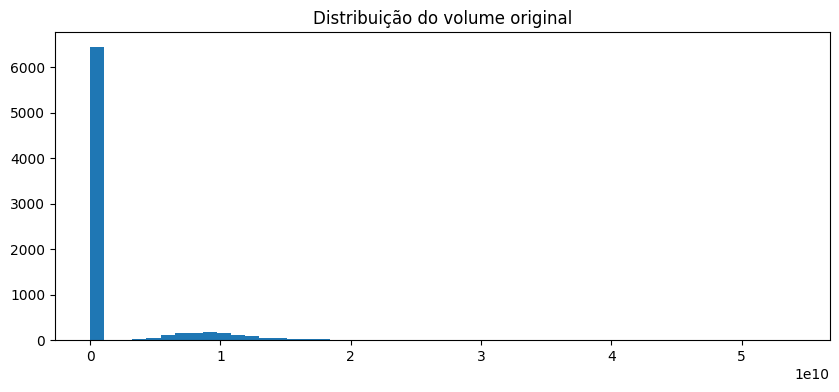

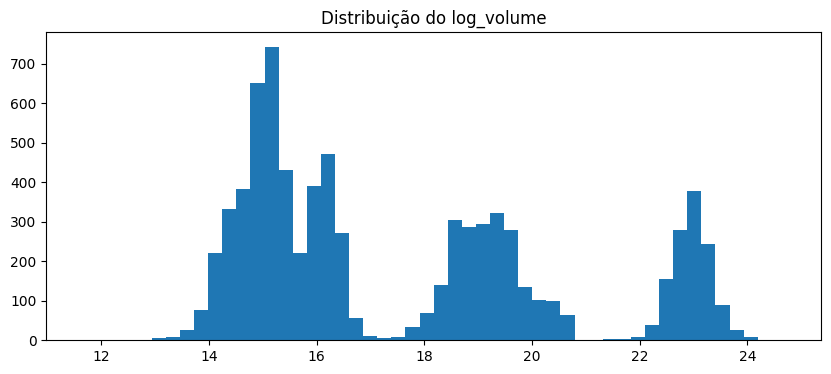

In [25]:
# ============================================================
# BLOCO — Comparação do Volume
# Objetivo:
# - comparar graficamente como estava e como ficou a distribuíção do volume
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(df_modelo["volume"], bins=50)
plt.title("Distribuição do volume original")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(df_modelo["log_volume"], bins=50)
plt.title("Distribuição do log_volume")
plt.show()

In [26]:
# ============================================================
# BLOCO — AVALIAÇÃO DE OUTLIERS
# Objetivo:
# - Identificar extremos nas principais variáveis numéricas
# ============================================================

colunas_analise = [
    "retorno_1d", "retorno_3d", "variacao_num",
    "volume", "log_volume", "amplitude_pct"
]

for col in colunas_analise:
    print(f"\n===== {col} =====")
    print(df_modelo[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))


===== retorno_1d =====
count    7677.000000
mean        0.000629
std         0.020015
min        -0.158090
1%         -0.051563
5%         -0.029345
50%         0.000827
95%         0.028250
99%         0.050949
max         0.334190
Name: retorno_1d, dtype: float64

===== retorno_3d =====
count    7677.000000
mean        0.001874
std         0.034622
min        -0.254273
1%         -0.096838
5%         -0.049259
50%         0.002427
95%         0.049651
99%         0.090300
max         0.459561
Name: retorno_3d, dtype: float64

===== variacao_num =====
count    7677.000000
mean        0.000629
std         0.020015
min        -0.158100
1%         -0.051544
5%         -0.029300
50%         0.000800
95%         0.028220
99%         0.050924
max         0.334200
Name: variacao_num, dtype: float64

===== volume =====
count    7.677000e+03
mean     1.696368e+09
std      4.008215e+09
min      1.121000e+05
1%       1.070000e+06
5%       1.590000e+06
50%      1.152000e+07
95%      1.112000e+10

## Leitura da avaliação de outliers

A análise mostra que as variáveis **retorno_1d**, **retorno_3d** e **amplitude_pct** apresentam alguns valores extremos, o que é esperado em séries financeiras, especialmente em períodos de maior volatilidade. Em geral, essas variáveis permanecem utilizáveis na modelagem.

A variável **volume** foi a que apresentou maior assimetria e presença de outliers, com valores máximos muito distantes da mediana. Por esse motivo, a transformação em **log_volume** se mostrou adequada, pois reduziu a dispersão e tornou a variável mais estável para uso em modelos sensíveis à escala.

Observou-se também que **variacao_num** é muito semelhante a **retorno_1d**, indicando possível redundância. Assim, pode ser interessante manter apenas uma das duas no conjunto final de variáveis.

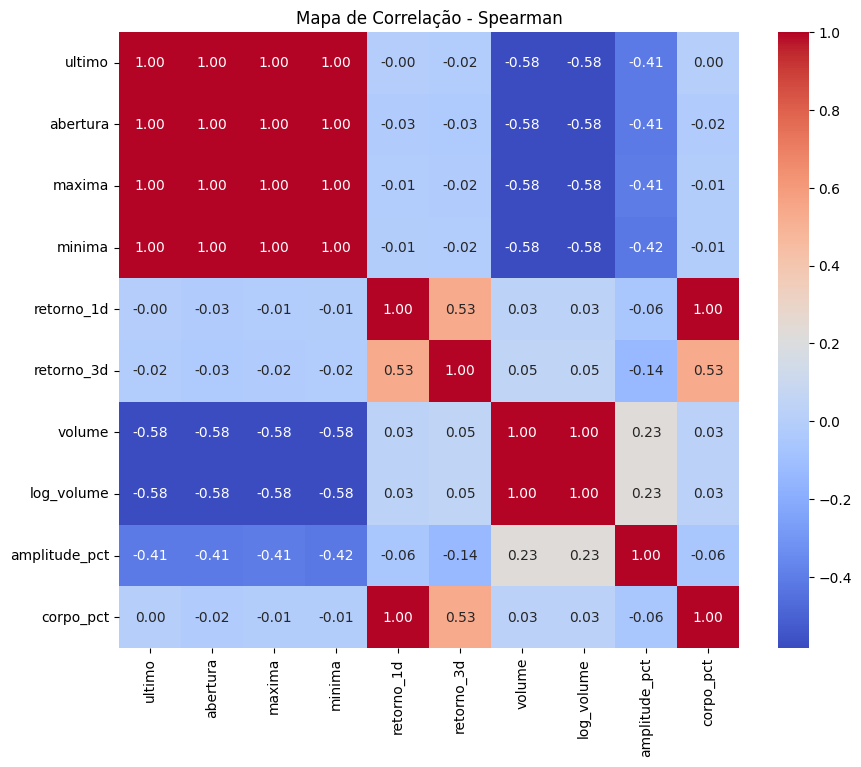

In [27]:
# ============================================================
# BLOCO — CORRELAÇÃO ENTRE VARIÁVEIS
# Objetivo:
# - Identificar colunas muito correlacionadas
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

colunas_corr = [
    "ultimo", "abertura", "maxima", "minima",
    "retorno_1d", "retorno_3d",
    "volume", "log_volume",
    "amplitude_pct", "corpo_pct"
]

corr = df_modelo[colunas_corr].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Correlação - Spearman")
plt.show()

## Leitura do mapa de correlação

O mapa de correlação de Spearman mostra forte redundância entre algumas variáveis. As colunas **ultimo**, **abertura**, **maxima** e **minima** apresentam correlação praticamente perfeita entre si, indicando que carregam informação muito semelhante. Por esse motivo, não é necessário manter todas no modelo.

Também foi observada correlação praticamente perfeita entre **retorno_1d** e **corpo_pct**, sugerindo redundância. Nesse caso, faz sentido manter apenas uma das duas, preferencialmente **retorno_1d**, por ser mais interpretável.

As variáveis **volume** e **log_volume** também são altamente redundantes. Como **log_volume** é uma versão transformada mais estável, ela tende a ser mais adequada para modelagem.

Por outro lado, **amplitude_pct** apresentou baixa correlação com a maioria das demais variáveis, o que sugere que pode acrescentar informação complementar ao modelo.

Com base nisso, a recomendação é reduzir a redundância da base, priorizando variáveis derivadas e mais informativas.

In [28]:
# ============================================================
# BLOCO — MONTAGEM DA BASE FINAL DE MODELAGEM
# Objetivo:
# - Reduzir redundância
# - Manter variáveis mais informativas
# - Gerar base final pronta para treino/teste
# ============================================================

df_base_final = df_modelo.copy()

features_finais = [
    "retorno_1d",
    "retorno_3d",
    "dist_mm_7",
    "cruz_mm_3_7",
    "amplitude_pct",
    "sombra_sup_pct",
    "sombra_inf_pct",
    "volume_ret_1d",
    "log_volume",
    "volume_mm_7",
    "dow",
    "month"
]

target = "tendencia"

colunas_finais = ["data"] + features_finais + [target]

df_base_final = df_base_final[colunas_finais].dropna().copy()
df_base_final = df_base_final.sort_values("data").reset_index(drop=True)

print("Dimensão da base final:", df_base_final.shape)
print("\nColunas da base final:")
print(df_base_final.columns.tolist())

print("\nValores nulos por coluna:")
print(df_base_final.isnull().sum())

print("\nAmostra da base final:")
print(df_base_final.head())

Dimensão da base final: (7677, 14)

Colunas da base final:
['data', 'retorno_1d', 'retorno_3d', 'dist_mm_7', 'cruz_mm_3_7', 'amplitude_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'volume_ret_1d', 'log_volume', 'volume_mm_7', 'dow', 'month', 'tendencia']

Valores nulos por coluna:
data              0
retorno_1d        0
retorno_3d        0
dist_mm_7         0
cruz_mm_3_7       0
amplitude_pct     0
sombra_sup_pct    0
sombra_inf_pct    0
volume_ret_1d     0
log_volume        0
volume_mm_7       0
dow               0
month             0
tendencia         0
dtype: int64

Amostra da base final:
        data  retorno_1d  retorno_3d  dist_mm_7  cruz_mm_3_7  amplitude_pct  \
0 1994-09-16    0.001135   -0.039376  -0.017107    -0.006215       0.037590   
1 1994-09-19   -0.000378   -0.033601  -0.018000    -0.018123       0.017952   
2 1994-09-20   -0.021731   -0.020991  -0.034888    -0.020471       0.025691   
3 1994-09-21    0.024918    0.002267  -0.005409    -0.014344       0.027516   
4 1994-09

In [29]:
# ============================================================
# BLOCO — CONFERÊNCIA DA BASE FINAL
# ============================================================

print("Período da base final:")
print("Data mínima:", df_base_final["data"].min())
print("Data máxima:", df_base_final["data"].max())

print("\nDistribuição da variável alvo:")
print(df_base_final["tendencia"].value_counts())
print(df_base_final["tendencia"].value_counts(normalize=True).round(4))

Período da base final:
Data mínima: 1994-09-16 00:00:00
Data máxima: 2025-09-15 00:00:00

Distribuição da variável alvo:
tendencia
1    4000
0    3677
Name: count, dtype: int64
tendencia
1    0.521
0    0.479
Name: proportion, dtype: float64


## Definição da base final de modelagem

Com base na análise de outliers e no mapa de correlação, foi definida uma base final mais enxuta, priorizando variáveis derivadas e reduzindo redundâncias.

Foram removidas variáveis com alta sobreposição de informação, como preços brutos altamente correlacionados entre si, além de colunas redundantes como **volume** em relação a **log_volume** e **corpo_pct** em relação a **retorno_1d**.

A base final passou a concentrar variáveis mais adequadas para modelagem, incluindo retornos, distâncias para médias móveis, amplitude do candle, sombras, medidas relativas de volume e variáveis temporais.

In [30]:
print(df_base_final.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7677 entries, 0 to 7676
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            7677 non-null   datetime64[ns]
 1   retorno_1d      7677 non-null   float64       
 2   retorno_3d      7677 non-null   float64       
 3   dist_mm_7       7677 non-null   float64       
 4   cruz_mm_3_7     7677 non-null   float64       
 5   amplitude_pct   7677 non-null   float64       
 6   sombra_sup_pct  7677 non-null   float64       
 7   sombra_inf_pct  7677 non-null   float64       
 8   volume_ret_1d   7677 non-null   float64       
 9   log_volume      7677 non-null   float64       
 10  volume_mm_7     7677 non-null   float64       
 11  dow             7677 non-null   int32         
 12  month           7677 non-null   int32         
 13  tendencia       7677 non-null   int64         
dtypes: datetime64[ns](1), float64(10), int32(2), int64(1)
me

## Conferência da base final

A base final de modelagem foi gerada com sucesso, contendo **7.677 registros** e **14 colunas**, sendo **12 variáveis preditoras**, a coluna **data** para controle temporal e a variável alvo **tendencia**.

Todas as colunas estão com tipos adequados para modelagem, não há valores nulos e a base está pronta para a próxima etapa de separação temporal entre treino, validação e teste.


In [31]:
# ============================================================
# BLOCO — RECORTES TEMPORAIS DA BASE FINAL
# Objetivo:
# - Comparar base completa com janelas mais recentes
# ============================================================

df_base_completa = df_base_final.copy()
df_base_10a = df_base_final[df_base_final["data"] >= "2015-01-01"].copy()
df_base_5a = df_base_final[df_base_final["data"] >= "2020-01-01"].copy()

print("Base completa:", df_base_completa.shape)
print("Período:", df_base_completa["data"].min(), "até", df_base_completa["data"].max())

print("\nBase 10 anos:", df_base_10a.shape)
print("Período:", df_base_10a["data"].min(), "até", df_base_10a["data"].max())

print("\nBase 5 anos:", df_base_5a.shape)
print("Período:", df_base_5a["data"].min(), "até", df_base_5a["data"].max())

Base completa: (7677, 14)
Período: 1994-09-16 00:00:00 até 2025-09-15 00:00:00

Base 10 anos: (2656, 14)
Período: 2015-01-02 00:00:00 até 2025-09-15 00:00:00

Base 5 anos: (1422, 14)
Período: 2020-01-02 00:00:00 até 2025-09-15 00:00:00


## Definição dos recortes temporais

Como a série histórica cobre um período muito longo, de 1994 a 2025, optou-se por testar não apenas a base completa, mas também recortes temporais mais recentes.

Essa estratégia permite avaliar se padrões mais antigos ajudam ou atrapalham a capacidade preditiva do modelo, considerando que séries financeiras podem sofrer mudanças estruturais ao longo do tempo.

Foram definidos três cenários de base para comparação:
- base completa;
- últimos 10 anos;
- últimos 5 anos.

In [32]:
# ============================================================
# BLOCO — ORGANIZAÇÃO DOS CENÁRIOS DE BASE
# Objetivo:
# - Guardar os recortes em uma estrutura única
# - Facilitar os testes posteriores
# ============================================================

bases_modelagem = {
    "base_completa": df_base_completa,
    "base_10a": df_base_10a,
    "base_5a": df_base_5a
}

for nome, base in bases_modelagem.items():
    print(f"\n===== {nome} =====")
    print("Dimensão:", base.shape)
    print("Período:", base["data"].min(), "até", base["data"].max())
    print("Distribuição da tendência:")
    print(base["tendencia"].value_counts(normalize=True).round(4))


===== base_completa =====
Dimensão: (7677, 14)
Período: 1994-09-16 00:00:00 até 2025-09-15 00:00:00
Distribuição da tendência:
tendencia
1    0.521
0    0.479
Name: proportion, dtype: float64

===== base_10a =====
Dimensão: (2656, 14)
Período: 2015-01-02 00:00:00 até 2025-09-15 00:00:00
Distribuição da tendência:
tendencia
1    0.5203
0    0.4797
Name: proportion, dtype: float64

===== base_5a =====
Dimensão: (1422, 14)
Período: 2020-01-02 00:00:00 até 2025-09-15 00:00:00
Distribuição da tendência:
tendencia
1    0.5113
0    0.4887
Name: proportion, dtype: float64


## Criação dos recortes temporais

A base final foi organizada em três cenários de análise:

- **base completa**: série histórica integral;
- **base_10a**: dados a partir de 2015;
- **base_5a**: dados a partir de 2020.

Essa estratégia permite comparar se o uso de toda a série histórica é mais vantajoso do que trabalhar com janelas mais recentes, considerando que o comportamento do mercado pode mudar ao longo do tempo.

In [33]:
# ============================================================
# BLOCO — FUNÇÃO DE SPLIT TEMPORAL
# Objetivo:
# - Separar base em treino, validação e teste final
# - Preservar a ordem temporal
# ============================================================

def split_temporal(df, n_teste=30, n_validacao=90):
    df = df.sort_values("data").reset_index(drop=True).copy()

    if len(df) <= (n_teste + n_validacao):
        raise ValueError("Base muito pequena para o split escolhido.")

    df_treino = df.iloc[:-(n_validacao + n_teste)].copy()
    df_validacao = df.iloc[-(n_validacao + n_teste):-n_teste].copy()
    df_teste = df.iloc[-n_teste:].copy()

    return df_treino, df_validacao, df_teste

In [34]:
# ============================================================
# BLOCO — APLICAR SPLIT NAS BASES
# Objetivo:
# - Criar treino, validação e teste para cada cenário
# ============================================================

splits_bases = {}

for nome, base in bases_modelagem.items():
    treino, validacao, teste = split_temporal(base, n_teste=30, n_validacao=90)

    splits_bases[nome] = {
        "treino": treino,
        "validacao": validacao,
        "teste": teste
    }

    print(f"\n===== {nome} =====")
    print("Treino:", treino.shape, "|", treino["data"].min(), "até", treino["data"].max())
    print("Validação:", validacao.shape, "|", validacao["data"].min(), "até", validacao["data"].max())
    print("Teste:", teste.shape, "|", teste["data"].min(), "até", teste["data"].max())


===== base_completa =====
Treino: (7557, 14) | 1994-09-16 00:00:00 até 2025-03-25 00:00:00
Validação: (90, 14) | 2025-03-26 00:00:00 até 2025-08-04 00:00:00
Teste: (30, 14) | 2025-08-05 00:00:00 até 2025-09-15 00:00:00

===== base_10a =====
Treino: (2536, 14) | 2015-01-02 00:00:00 até 2025-03-25 00:00:00
Validação: (90, 14) | 2025-03-26 00:00:00 até 2025-08-04 00:00:00
Teste: (30, 14) | 2025-08-05 00:00:00 até 2025-09-15 00:00:00

===== base_5a =====
Treino: (1302, 14) | 2020-01-02 00:00:00 até 2025-03-25 00:00:00
Validação: (90, 14) | 2025-03-26 00:00:00 até 2025-08-04 00:00:00
Teste: (30, 14) | 2025-08-05 00:00:00 até 2025-09-15 00:00:00


In [35]:
# ============================================================
# BLOCO — SEPARAÇÃO DE FEATURES E TARGET
# Objetivo:
# - Preparar X e y para treino, validação e teste
# ============================================================

dados_modelagem = {}

for nome, partes in splits_bases.items():
    treino = partes["treino"]
    validacao = partes["validacao"]
    teste = partes["teste"]

    X_train = treino.drop(columns=["data", "tendencia"])
    y_train = treino["tendencia"]

    X_val = validacao.drop(columns=["data", "tendencia"])
    y_val = validacao["tendencia"]

    X_test = teste.drop(columns=["data", "tendencia"])
    y_test = teste["tendencia"]

    dados_modelagem[nome] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }

    print(f"\n===== {nome} =====")
    print("X_train:", X_train.shape, "| y_train:", y_train.shape)
    print("X_val:", X_val.shape, "| y_val:", y_val.shape)
    print("X_test:", X_test.shape, "| y_test:", y_test.shape)


===== base_completa =====
X_train: (7557, 12) | y_train: (7557,)
X_val: (90, 12) | y_val: (90,)
X_test: (30, 12) | y_test: (30,)

===== base_10a =====
X_train: (2536, 12) | y_train: (2536,)
X_val: (90, 12) | y_val: (90,)
X_test: (30, 12) | y_test: (30,)

===== base_5a =====
X_train: (1302, 12) | y_train: (1302,)
X_val: (90, 12) | y_val: (90,)
X_test: (30, 12) | y_test: (30,)


## Separação temporal em treino, validação e teste

Para evitar contaminação do teste final, a base foi dividida de forma temporal em três partes:

- **treino**: período mais antigo, usado para ajuste do modelo;
- **validação**: período intermediário, usado para comparar modelos e definir hiperparâmetros e threshold;
- **teste final**: últimos 30 registros, reservado exclusivamente para a avaliação final.

Essa separação preserva a ordem cronológica da série e evita o uso indevido do conjunto de teste durante o processo de calibração do modelo.

In [36]:
# ============================================================
# BLOCO — TREINO E AVALIAÇÃO DOS MODELOS NA VALIDAÇÃO
# Objetivo:
# - Treinar poucos modelos candidatos
# - Avaliar desempenho na validação
# - Comparar bases e modelos sem tocar no teste final
# ============================================================

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

modelos = {
    "KNN_k15": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance"))
    ]),

    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    )
}

resultados_validacao = []

for nome_base, dados in dados_modelagem.items():
    X_train = dados["X_train"]
    y_train = dados["y_train"]
    X_val = dados["X_val"]
    y_val = dados["y_val"]

    for nome_modelo, modelo in modelos.items():
        modelo.fit(X_train, y_train)

        prob_val = modelo.predict_proba(X_val)[:, 1]
        pred_val = (prob_val >= 0.50).astype(int)

        acc = accuracy_score(y_val, pred_val)
        bal_acc = balanced_accuracy_score(y_val, pred_val)
        auc = roc_auc_score(y_val, prob_val)

        resultados_validacao.append({
            "base": nome_base,
            "modelo": nome_modelo,
            "accuracy_val": acc,
            "balanced_accuracy_val": bal_acc,
            "auc_val": auc
        })

df_resultados_validacao = pd.DataFrame(resultados_validacao)
df_resultados_validacao = df_resultados_validacao.sort_values(
    by=["accuracy_val", "balanced_accuracy_val", "auc_val"],
    ascending=False
).reset_index(drop=True)

print(df_resultados_validacao)

             base        modelo  accuracy_val  balanced_accuracy_val   auc_val
0         base_5a  RandomForest      0.522222               0.528162  0.497036
1        base_10a  RandomForest      0.511111               0.517787  0.523715
2   base_completa    ExtraTrees      0.500000               0.510870  0.607708
3        base_10a        LogReg      0.488889               0.500000  0.544960
4        base_10a    ExtraTrees      0.488889               0.500000  0.504941
5   base_completa        LogReg      0.488889               0.500000  0.501976
6         base_5a    ExtraTrees      0.488889               0.500000  0.480731
7   base_completa  RandomForest      0.488889               0.499506  0.560771
8   base_completa       KNN_k15      0.488889               0.496047  0.520751
9         base_5a        LogReg      0.466667               0.476779  0.413538
10       base_10a       KNN_k15      0.444444               0.451087  0.472332
11        base_5a       KNN_k15      0.444444       

In [37]:
# ============================================================
# BLOCO — TOP RESULTADOS NA VALIDAÇÃO
# ============================================================

print(df_resultados_validacao.head(10))

            base        modelo  accuracy_val  balanced_accuracy_val   auc_val
0        base_5a  RandomForest      0.522222               0.528162  0.497036
1       base_10a  RandomForest      0.511111               0.517787  0.523715
2  base_completa    ExtraTrees      0.500000               0.510870  0.607708
3       base_10a        LogReg      0.488889               0.500000  0.544960
4       base_10a    ExtraTrees      0.488889               0.500000  0.504941
5  base_completa        LogReg      0.488889               0.500000  0.501976
6        base_5a    ExtraTrees      0.488889               0.500000  0.480731
7  base_completa  RandomForest      0.488889               0.499506  0.560771
8  base_completa       KNN_k15      0.488889               0.496047  0.520751
9        base_5a        LogReg      0.466667               0.476779  0.413538


## Treinamento inicial dos modelos candidatos

Nesta etapa, foram testados poucos modelos candidatos, escolhidos por serem adequados ao problema e complementares entre si:

- KNN com padronização;
- Regressão Logística com padronização;
- Random Forest;
- ExtraTrees.

A comparação foi feita apenas no conjunto de validação, preservando o teste final para a etapa conclusiva. Foram consideradas as métricas de acurácia, acurácia balanceada e AUC.

In [38]:
# ============================================================
# BLOCO — CRIAÇÃO DA BASE AMPLIADA
# Objetivo:
# - Reintroduzir variáveis que podem estar ajudando a modelagem
# ============================================================

features_ampliadas = [
    "ultimo",
    "abertura",
    "maxima",
    "minima",
    "retorno_1d",
    "retorno_3d",
    "dist_mm_7",
    "cruz_mm_3_7",
    "amplitude_pct",
    "sombra_sup_pct",
    "sombra_inf_pct",
    "volume_ret_1d",
    "log_volume",
    "volume_mm_7",
    "dow",
    "month"
]

# Adicione estas se existirem no seu df_modelo
extras_opcionais = [
    "mm_3",
    "mm_7",
    "rsi",
    "macd",
    "macd_signal"
]

for col in extras_opcionais:
    if col in df_modelo.columns and col not in features_ampliadas:
        features_ampliadas.append(col)

target = "tendencia"

colunas_base_ampliada = ["data"] + features_ampliadas + [target]

df_base_ampliada = df_modelo[colunas_base_ampliada].dropna().copy()
df_base_ampliada = df_base_ampliada.sort_values("data").reset_index(drop=True)

print("Dimensão da base ampliada:", df_base_ampliada.shape)
print(df_base_ampliada.columns.tolist())

Dimensão da base ampliada: (7677, 20)
['data', 'ultimo', 'abertura', 'maxima', 'minima', 'retorno_1d', 'retorno_3d', 'dist_mm_7', 'cruz_mm_3_7', 'amplitude_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'volume_ret_1d', 'log_volume', 'volume_mm_7', 'dow', 'month', 'macd', 'macd_signal', 'tendencia']


In [39]:
# ============================================================
# BLOCO — RECORTES DA BASE AMPLIADA
# ============================================================

df_base_ampliada_completa = df_base_ampliada.copy()
df_base_ampliada_10a = df_base_ampliada[df_base_ampliada["data"] >= "2015-01-01"].copy()
df_base_ampliada_5a  = df_base_ampliada[df_base_ampliada["data"] >= "2020-01-01"].copy()

bases_ampliadas = {
    "ampliada_completa": df_base_ampliada_completa,
    "ampliada_10a": df_base_ampliada_10a,
    "ampliada_5a": df_base_ampliada_5a
}

for nome, base in bases_ampliadas.items():
    print(f"\n===== {nome} =====")
    print("Dimensão:", base.shape)
    print("Período:", base["data"].min(), "até", base["data"].max())


===== ampliada_completa =====
Dimensão: (7677, 20)
Período: 1994-09-16 00:00:00 até 2025-09-15 00:00:00

===== ampliada_10a =====
Dimensão: (2656, 20)
Período: 2015-01-02 00:00:00 até 2025-09-15 00:00:00

===== ampliada_5a =====
Dimensão: (1422, 20)
Período: 2020-01-02 00:00:00 até 2025-09-15 00:00:00


In [40]:
# ============================================================
# BLOCO — SPLIT TEMPORAL DA BASE AMPLIADA
# ============================================================

splits_ampliados = {}

for nome, base in bases_ampliadas.items():
    treino, validacao, teste = split_temporal(base, n_teste=30, n_validacao=90)

    splits_ampliados[nome] = {
        "treino": treino,
        "validacao": validacao,
        "teste": teste
    }

    print(f"\n===== {nome} =====")
    print("Treino:", treino.shape)
    print("Validação:", validacao.shape)
    print("Teste:", teste.shape)


===== ampliada_completa =====
Treino: (7557, 20)
Validação: (90, 20)
Teste: (30, 20)

===== ampliada_10a =====
Treino: (2536, 20)
Validação: (90, 20)
Teste: (30, 20)

===== ampliada_5a =====
Treino: (1302, 20)
Validação: (90, 20)
Teste: (30, 20)


In [41]:
# ============================================================
# BLOCO — X E y DA BASE AMPLIADA
# ============================================================

dados_modelagem_ampliados = {}

for nome, partes in splits_ampliados.items():
    treino = partes["treino"]
    validacao = partes["validacao"]
    teste = partes["teste"]

    X_train = treino.drop(columns=["data", "tendencia"])
    y_train = treino["tendencia"]

    X_val = validacao.drop(columns=["data", "tendencia"])
    y_val = validacao["tendencia"]

    X_test = teste.drop(columns=["data", "tendencia"])
    y_test = teste["tendencia"]

    dados_modelagem_ampliados[nome] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }

    print(f"\n===== {nome} =====")
    print("X_train:", X_train.shape)
    print("X_val:", X_val.shape)
    print("X_test:", X_test.shape)


===== ampliada_completa =====
X_train: (7557, 18)
X_val: (90, 18)
X_test: (30, 18)

===== ampliada_10a =====
X_train: (2536, 18)
X_val: (90, 18)
X_test: (30, 18)

===== ampliada_5a =====
X_train: (1302, 18)
X_val: (90, 18)
X_test: (30, 18)


## Ajuste da base de modelagem

Os resultados iniciais com a base enxuta ficaram próximos do aleatório, indicando perda de capacidade preditiva. Diante disso, foi criada uma base ampliada, reintroduzindo variáveis de preço e indicadores adicionais, com o objetivo de recuperar sinal útil para os modelos.

Essa decisão foi tomada porque, em problemas financeiros, a remoção excessiva de variáveis pode simplificar a base, mas também reduzir informação relevante para a previsão.


In [42]:
# ============================================================
# BLOCO — TREINO E AVALIAÇÃO DOS MODELOS NA VALIDAÇÃO
# BASE AMPLIADA
# Objetivo:
# - Reavaliar os modelos após ampliar as features
# - Comparar desempenho na validação
# ============================================================

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

modelos = {
    "KNN_k15": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance"))
    ]),

    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42
    )
}

resultados_validacao_ampliada = []

for nome_base, dados in dados_modelagem_ampliados.items():
    X_train = dados["X_train"]
    y_train = dados["y_train"]
    X_val = dados["X_val"]
    y_val = dados["y_val"]

    for nome_modelo, modelo in modelos.items():
        modelo.fit(X_train, y_train)

        prob_val = modelo.predict_proba(X_val)[:, 1]
        pred_val = (prob_val >= 0.50).astype(int)

        acc = accuracy_score(y_val, pred_val)
        bal_acc = balanced_accuracy_score(y_val, pred_val)
        auc = roc_auc_score(y_val, prob_val)

        resultados_validacao_ampliada.append({
            "base": nome_base,
            "modelo": nome_modelo,
            "accuracy_val": acc,
            "balanced_accuracy_val": bal_acc,
            "auc_val": auc
        })

df_resultados_validacao_ampliada = pd.DataFrame(resultados_validacao_ampliada)
df_resultados_validacao_ampliada = df_resultados_validacao_ampliada.sort_values(
    by=["accuracy_val", "balanced_accuracy_val", "auc_val"],
    ascending=False
).reset_index(drop=True)

print(df_resultados_validacao_ampliada)

                 base        modelo  accuracy_val  balanced_accuracy_val  \
0   ampliada_completa  RandomForest      0.566667               0.571640   
1         ampliada_5a       KNN_k15      0.522222               0.526680   
2         ampliada_5a  RandomForest      0.522222               0.520751   
3        ampliada_10a  RandomForest      0.511111               0.512352   
4   ampliada_completa    ExtraTrees      0.500000               0.510870   
5         ampliada_5a    ExtraTrees      0.500000               0.510870   
6        ampliada_10a    ExtraTrees      0.500000               0.510870   
7        ampliada_10a       KNN_k15      0.500000               0.505435   
8   ampliada_completa        LogReg      0.488889               0.500000   
9        ampliada_10a        LogReg      0.477778               0.488636   
10        ampliada_5a        LogReg      0.466667               0.476285   
11  ampliada_completa       KNN_k15      0.466667               0.474802   

     auc_va

In [43]:
# ============================================================
# BLOCO — TOP RESULTADOS DA VALIDAÇÃO
# BASE AMPLIADA
# ============================================================

print(df_resultados_validacao_ampliada.head(10))

                base        modelo  accuracy_val  balanced_accuracy_val  \
0  ampliada_completa  RandomForest      0.566667               0.571640   
1        ampliada_5a       KNN_k15      0.522222               0.526680   
2        ampliada_5a  RandomForest      0.522222               0.520751   
3       ampliada_10a  RandomForest      0.511111               0.512352   
4  ampliada_completa    ExtraTrees      0.500000               0.510870   
5        ampliada_5a    ExtraTrees      0.500000               0.510870   
6       ampliada_10a    ExtraTrees      0.500000               0.510870   
7       ampliada_10a       KNN_k15      0.500000               0.505435   
8  ampliada_completa        LogReg      0.488889               0.500000   
9       ampliada_10a        LogReg      0.477778               0.488636   

    auc_val  
0  0.595356  
1  0.513834  
2  0.537549  
3  0.501976  
4  0.533597  
5  0.519269  
6  0.478261  
7  0.503953  
8  0.493083  
9  0.494071  


In [44]:
# ============================================================
# BLOCO — AJUSTE FINO DO RANDOMFOREST
# BASE: ampliada_completa
# Objetivo:
# - Melhorar o desempenho do melhor candidato atual
# ============================================================

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

# Seleciona a melhor base atual
dados_rf = dados_modelagem_ampliados["ampliada_completa"]

X_train = dados_rf["X_train"]
y_train = dados_rf["y_train"]
X_val = dados_rf["X_val"]
y_val = dados_rf["y_val"]

resultados_rf = []

parametros_rf = [
    {"n_estimators": 200, "max_depth": 6,  "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 6,  "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": 10, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 14, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 14, "min_samples_leaf": 3, "max_features": "log2"},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 3, "max_features": "log2"},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 5, "max_features": None},
]

for params in parametros_rf:
    modelo = RandomForestClassifier(
        random_state=42,
        **params
    )

    modelo.fit(X_train, y_train)

    prob_val = modelo.predict_proba(X_val)[:, 1]
    pred_val = (prob_val >= 0.50).astype(int)

    acc = accuracy_score(y_val, pred_val)
    bal_acc = balanced_accuracy_score(y_val, pred_val)
    auc = roc_auc_score(y_val, prob_val)

    resultados_rf.append({
        **params,
        "accuracy_val": acc,
        "balanced_accuracy_val": bal_acc,
        "auc_val": auc
    })

df_resultados_rf = pd.DataFrame(resultados_rf).sort_values(
    by=["accuracy_val", "balanced_accuracy_val", "auc_val"],
    ascending=False
).reset_index(drop=True)

print(df_resultados_rf)

   n_estimators  max_depth  min_samples_leaf max_features  accuracy_val  \
0           200        6.0                 1         sqrt      0.577778   
1           600       10.0                 3         sqrt      0.555556   
2           400       10.0                 3         sqrt      0.555556   
3           400        6.0                 1         sqrt      0.533333   
4           600        NaN                 1         sqrt      0.533333   
5           600        NaN                 5         None      0.522222   
6           400       14.0                 3         log2      0.511111   
7           400       14.0                 1         sqrt      0.500000   
8           600        NaN                 3         log2      0.500000   
9           400       10.0                 1         sqrt      0.466667   

   balanced_accuracy_val   auc_val  
0               0.580534  0.543972  
1               0.558300  0.555830  
2               0.557312  0.574111  
3               0.538043  

## Ajuste fino do melhor modelo

Como o melhor desempenho até aqui foi obtido com o modelo RandomForest na base ampliada completa, a etapa seguinte consistiu em realizar um ajuste fino controlado dos hiperparâmetros desse modelo.

Foram testadas diferentes combinações de profundidade máxima, número de árvores, número mínimo de amostras por folha e estratégia de seleção de variáveis, sempre avaliando o desempenho no conjunto de validação.

In [45]:
# ============================================================
# BLOCO — AJUSTE DE THRESHOLD NA VALIDAÇÃO
# MODELO: RandomForest vencedor
# BASE: ampliada_completa
# Objetivo:
# - Encontrar o melhor threshold usando apenas a validação
# ============================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

# Dados da melhor base
dados_rf = dados_modelagem_ampliados["ampliada_completa"]

X_train = dados_rf["X_train"]
y_train = dados_rf["y_train"]
X_val = dados_rf["X_val"]
y_val = dados_rf["y_val"]

# Melhor configuração encontrada
rf_final_val = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42
)

rf_final_val.fit(X_train, y_train)

prob_val = rf_final_val.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.02)

resultados_threshold = []

for th in thresholds:
    pred_val = (prob_val >= th).astype(int)

    acc = accuracy_score(y_val, pred_val)
    bal_acc = balanced_accuracy_score(y_val, pred_val)
    auc = roc_auc_score(y_val, prob_val)

    resultados_threshold.append({
        "threshold": round(th, 2),
        "accuracy_val": acc,
        "balanced_accuracy_val": bal_acc,
        "auc_val": auc
    })

df_thresholds = pd.DataFrame(resultados_threshold).sort_values(
    by=["accuracy_val", "balanced_accuracy_val"],
    ascending=False
).reset_index(drop=True)

print(df_thresholds)

    threshold  accuracy_val  balanced_accuracy_val   auc_val
0        0.50      0.577778               0.580534  0.543972
1        0.54      0.533333               0.524704  0.543972
2        0.58      0.522222               0.511858  0.543972
3        0.60      0.522222               0.511364  0.543972
4        0.62      0.511111               0.500000  0.543972
5        0.64      0.511111               0.500000  0.543972
6        0.66      0.511111               0.500000  0.543972
7        0.68      0.511111               0.500000  0.543972
8        0.70      0.511111               0.500000  0.543972
9        0.52      0.500000               0.495553  0.543972
10       0.56      0.500000               0.490119  0.543972
11       0.30      0.488889               0.500000  0.543972
12       0.32      0.488889               0.500000  0.543972
13       0.34      0.488889               0.500000  0.543972
14       0.36      0.488889               0.500000  0.543972
15       0.38      0.488

In [46]:
# ============================================================
# BLOCO — MELHOR THRESHOLD NA VALIDAÇÃO
# ============================================================

melhor_threshold = df_thresholds.iloc[0]["threshold"]

print("Melhor threshold na validação:", melhor_threshold)
print(df_thresholds.head(10))

Melhor threshold na validação: 0.5
   threshold  accuracy_val  balanced_accuracy_val   auc_val
0       0.50      0.577778               0.580534  0.543972
1       0.54      0.533333               0.524704  0.543972
2       0.58      0.522222               0.511858  0.543972
3       0.60      0.522222               0.511364  0.543972
4       0.62      0.511111               0.500000  0.543972
5       0.64      0.511111               0.500000  0.543972
6       0.66      0.511111               0.500000  0.543972
7       0.68      0.511111               0.500000  0.543972
8       0.70      0.511111               0.500000  0.543972
9       0.52      0.500000               0.495553  0.543972


## Ajuste do threshold na validação

Após definir o melhor modelo e a melhor configuração de hiperparâmetros, foi realizada a calibração do threshold de decisão utilizando exclusivamente o conjunto de validação.

Essa etapa permite ajustar o ponto de corte da probabilidade prevista sem contaminar o teste final, preservando a validade metodológica da avaliação conclusiva.

In [47]:
# ============================================================
# BLOCO — ENGENHARIA DE ATRIBUTOS AVANÇADA
# ============================================================

df_feat = df_modelo.copy()

# Médias móveis
df_feat["mm_3"] = df_feat["ultimo"].rolling(3).mean()
df_feat["mm_7"] = df_feat["ultimo"].rolling(7).mean()
df_feat["mm_14"] = df_feat["ultimo"].rolling(14).mean()

# Distância do preço para médias móveis
df_feat["dist_mm_3"] = (df_feat["ultimo"] / df_feat["mm_3"]) - 1
df_feat["dist_mm_7"] = (df_feat["ultimo"] / df_feat["mm_7"]) - 1
df_feat["dist_mm_14"] = (df_feat["ultimo"] / df_feat["mm_14"]) - 1

# Retornos adicionais
df_feat["retorno_5d"] = df_feat["ultimo"].pct_change(5)
df_feat["retorno_7d"] = df_feat["ultimo"].pct_change(7)

# Volatilidade
df_feat["vol_7"] = df_feat["retorno_1d"].rolling(7).std()
df_feat["vol_14"] = df_feat["retorno_1d"].rolling(14).std()

# Momentum
df_feat["momentum_3"] = df_feat["ultimo"] - df_feat["ultimo"].shift(3)
df_feat["momentum_5"] = df_feat["ultimo"] - df_feat["ultimo"].shift(5)
df_feat["momentum_7"] = df_feat["ultimo"] - df_feat["ultimo"].shift(7)

# Remover linhas com NaN geradas pelas janelas
df_feat = df_feat.dropna().reset_index(drop=True)

print("Shape após novas features:", df_feat.shape)
print(df_feat[[
    "ultimo", "mm_3", "mm_7", "mm_14",
    "dist_mm_3", "dist_mm_7", "dist_mm_14",
    "retorno_5d", "retorno_7d",
    "vol_7", "vol_14",
    "momentum_3", "momentum_5", "momentum_7"
]].head())

Shape após novas features: (7664, 42)
   ultimo         mm_3         mm_7        mm_14  dist_mm_3  dist_mm_7  \
0  4979.0  5160.333333  5271.857143  5291.785714  -0.035140  -0.055551   
1  4877.0  5007.666667  5223.142857  5262.000000  -0.026093  -0.066271   
2  5032.0  4962.666667  5188.142857  5243.428571   0.013971  -0.030096   
3  4926.0  4945.000000  5114.285714  5225.500000  -0.003842  -0.036816   
4  4945.0  4967.666667  5037.285714  5199.714286  -0.004563  -0.018321   

   dist_mm_14  retorno_5d  retorno_7d     vol_7    vol_14  momentum_3  \
0   -0.059108   -0.056471   -0.054321  0.025482  0.022800      -505.0   
1   -0.073166   -0.103987   -0.065351  0.025947  0.023152      -458.0   
2   -0.040323   -0.082422   -0.046428  0.029562  0.025213      -135.0   
3   -0.057315   -0.076664   -0.094984  0.024603  0.025176       -53.0   
4   -0.048986   -0.042965   -0.098286  0.024104  0.023963        68.0   

   momentum_5  momentum_7  
0      -298.0      -286.0  
1      -566.0      -34

In [48]:
# ============================================================
# BLOCO — VERIFICAR COLUNAS DISPONÍVEIS
# ============================================================

print(sorted(df_feat.columns))

['abertura', 'amplitude_pct', 'corpo_pct', 'cruz_mm_3_7', 'data', 'dist_mm_14', 'dist_mm_3', 'dist_mm_7', 'dow', 'log_volume', 'macd', 'macd_diff', 'macd_signal', 'maxima', 'media_movel_3', 'media_movel_7', 'minima', 'mm_14', 'mm_3', 'mm_7', 'momentum_3', 'momentum_5', 'momentum_7', 'month', 'retorno_1d', 'retorno_3d', 'retorno_5d', 'retorno_7d', 'rsi_14', 'sombra_inf_pct', 'sombra_sup_pct', 'tendencia', 'ultimo', 'variacao', 'variacao_num', 'vol_14', 'vol_7', 'volatilidade_3d', 'volatilidade_7d', 'volume', 'volume_mm_7', 'volume_ret_1d']


In [49]:
# ============================================================
# BLOCO — DEFINIR TARGET E FEATURES COM BASE NAS COLUNAS REAIS
# ============================================================

df_modelagem = df_feat.copy()

# Ajuste do alvo
# Opção 1: usar "tendencia" se estiver como texto (ex.: Alta/Baixa)
# Opção 2: usar "variacao_num" para gerar binário
if "target" not in df_modelagem.columns:
    if "tendencia" in df_modelagem.columns:
        df_modelagem["target"] = (
            df_modelagem["tendencia"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "alta": 1,
                "baixa": 0,
                "1": 1,
                "0": 0
            })
        )
    elif "variacao_num" in df_modelagem.columns:
        df_modelagem["target"] = (df_modelagem["variacao_num"] > 0).astype(int)

# Lista de features baseada no que realmente existe
colunas_features = [
    "retorno_1d",
    "retorno_3d",
    "retorno_5d",
    "retorno_7d",
    "amplitude_pct",
    "corpo_pct",
    "sombra_sup_pct",
    "sombra_inf_pct",
    "log_volume",
    "dow",
    "month",
    "mm_3",
    "mm_7",
    "mm_14",
    "dist_mm_3",
    "dist_mm_7",
    "dist_mm_14",
    "vol_7",
    "vol_14",
    "momentum_3",
    "momentum_5",
    "momentum_7",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_diff",
    "cruz_mm_3_7",
    "volatilidade_3d",
    "volatilidade_7d",
    "volume_mm_7",
    "volume_ret_1d"
]

# Mantém só as que existem
colunas_features = [c for c in colunas_features if c in df_modelagem.columns]

# Remove linhas com target ausente, se houver
df_modelagem = df_modelagem.dropna(subset=["target"]).copy()

print("Target criado com sucesso.")
print("Distribuição do target:")
print(df_modelagem["target"].value_counts(dropna=False).sort_index())

print("\nQuantidade de features:", len(colunas_features))
print("Features usadas:")
print(colunas_features)

Target criado com sucesso.
Distribuição do target:
target
0    3670
1    3994
Name: count, dtype: int64

Quantidade de features: 31
Features usadas:
['retorno_1d', 'retorno_3d', 'retorno_5d', 'retorno_7d', 'amplitude_pct', 'corpo_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'log_volume', 'dow', 'month', 'mm_3', 'mm_7', 'mm_14', 'dist_mm_3', 'dist_mm_7', 'dist_mm_14', 'vol_7', 'vol_14', 'momentum_3', 'momentum_5', 'momentum_7', 'rsi_14', 'macd', 'macd_signal', 'macd_diff', 'cruz_mm_3_7', 'volatilidade_3d', 'volatilidade_7d', 'volume_mm_7', 'volume_ret_1d']


In [50]:
# ============================================================
# BLOCO — SPLIT TEMPORAL
# ============================================================

n_total = len(df_modelagem)
n_teste = 30
n_val = int((n_total - n_teste) * 0.2)

df_treino = df_modelagem.iloc[: n_total - n_teste - n_val].copy()
df_val = df_modelagem.iloc[n_total - n_teste - n_val : n_total - n_teste].copy()
df_teste = df_modelagem.iloc[n_total - n_teste :].copy()

X_train = df_treino[colunas_features]
y_train = df_treino["target"]

X_val = df_val[colunas_features]
y_val = df_val["target"]

X_test = df_teste[colunas_features]
y_test = df_teste["target"]

print("Treino   :", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste    :", X_test.shape, y_test.shape)

print("\nPeríodos:")
print("Treino   :", df_treino["data"].min(), "até", df_treino["data"].max())
print("Validação:", df_val["data"].min(), "até", df_val["data"].max())
print("Teste    :", df_teste["data"].min(), "até", df_teste["data"].max())

Treino   : (6108, 31) (6108,)
Validação: (1526, 31) (1526,)
Teste    : (30, 31) (30,)

Períodos:
Treino   : 1994-10-06 00:00:00 até 2019-06-17 00:00:00
Validação: 2019-06-18 00:00:00 até 2025-08-04 00:00:00
Teste    : 2025-08-05 00:00:00 até 2025-09-15 00:00:00


In [51]:
# ============================================================
# BLOCO — TREINAR RANDOMFOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

proba_val = rf.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.5).astype(int)

acc_val = accuracy_score(y_val, pred_val)
bacc_val = balanced_accuracy_score(y_val, pred_val)
auc_val = roc_auc_score(y_val, proba_val)

print("Accuracy validação         :", round(acc_val, 4))
print("Balanced accuracy validação:", round(bacc_val, 4))
print("AUC validação              :", round(auc_val, 4))

Accuracy validação         : 0.5039
Balanced accuracy validação: 0.5117
AUC validação              : 0.5144


In [52]:
# ============================================================
# BLOCO — IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

import pandas as pd

df_importancias = pd.DataFrame({
    "feature": colunas_features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(df_importancias.head(15))

          feature  importance
3      retorno_7d    0.046471
26    cruz_mm_3_7    0.046228
25      macd_diff    0.045253
16     dist_mm_14    0.043375
19     momentum_3    0.038626
21     momentum_7    0.038006
0      retorno_1d    0.037488
22         rsi_14    0.036337
23           macd    0.036326
1      retorno_3d    0.036162
30  volume_ret_1d    0.036062
4   amplitude_pct    0.035110
29    volume_mm_7    0.034460
15      dist_mm_7    0.034326
5       corpo_pct    0.034162


In [53]:
# ============================================================
# BLOCO — PREPARAÇÃO DAS FEATURES
# Objetivo:
# - Separar variáveis preditoras e alvo
# ============================================================

features = [
    "retorno_1d", "retorno_3d", "dist_mm_7", "cruz_mm_3_7",
    "amplitude_pct", "corpo_pct", "sombra_sup_pct", "sombra_inf_pct",
    "volume_ret_1d", "log_volume", "dow", "month"
]

target = "tendencia"

df_base_final = df_modelo[["data"] + features + [target]].dropna().copy()

print("Dimensão da base final:", df_base_final.shape)
print(df_base_final.head())

Dimensão da base final: (7677, 14)
        data  retorno_1d  retorno_3d  dist_mm_7  cruz_mm_3_7  amplitude_pct  \
0 1994-09-16    0.001135   -0.039376  -0.017107    -0.006215       0.037590   
1 1994-09-19   -0.000378   -0.033601  -0.018000    -0.018123       0.017952   
2 1994-09-20   -0.021731   -0.020991  -0.034888    -0.020471       0.025691   
3 1994-09-21    0.024918    0.002267  -0.005409    -0.014344       0.027516   
4 1994-09-22    0.016773    0.019463   0.014425    -0.004817       0.023170   

   corpo_pct  sombra_sup_pct  sombra_inf_pct  volume_ret_1d  log_volume  dow  \
0   0.001135        0.024556        0.011900       0.156455   23.081286    4   
1  -0.000378        0.011338        0.006236      -0.392621   22.582684    0   
2  -0.021731        0.000773        0.002704       0.188474   22.755354    1   
3   0.024918        0.002262        0.000942       1.595020   23.708948    2   
4   0.009543        0.006117        0.007600      -0.379293   23.232052    3   

   month 

In [54]:
# ============================================================
# BLOCO — MONTAGEM DA BASE FINAL DE MODELAGEM
# Objetivo:
# - Reduzir redundância
# - Manter variáveis mais informativas
# - Gerar base final pronta para treino/teste
# ============================================================

df_base_final = df_modelo.copy()

features_finais = [
    "retorno_1d",
    "retorno_3d",
    "dist_mm_7",
    "cruz_mm_3_7",
    "amplitude_pct",
    "sombra_sup_pct",
    "sombra_inf_pct",
    "volume_ret_1d",
    "log_volume",
    "volume_mm_7",
    "dow",
    "month"
]

target = "tendencia"

colunas_finais = ["data"] + features_finais + [target]

df_base_final = df_base_final[colunas_finais].dropna().copy()
df_base_final = df_base_final.sort_values("data").reset_index(drop=True)

print("Dimensão da base final:", df_base_final.shape)
print("\nColunas da base final:")
print(df_base_final.columns.tolist())

print("\nValores nulos por coluna:")
print(df_base_final.isnull().sum())

print("\nAmostra da base final:")
print(df_base_final.head())

Dimensão da base final: (7677, 14)

Colunas da base final:
['data', 'retorno_1d', 'retorno_3d', 'dist_mm_7', 'cruz_mm_3_7', 'amplitude_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'volume_ret_1d', 'log_volume', 'volume_mm_7', 'dow', 'month', 'tendencia']

Valores nulos por coluna:
data              0
retorno_1d        0
retorno_3d        0
dist_mm_7         0
cruz_mm_3_7       0
amplitude_pct     0
sombra_sup_pct    0
sombra_inf_pct    0
volume_ret_1d     0
log_volume        0
volume_mm_7       0
dow               0
month             0
tendencia         0
dtype: int64

Amostra da base final:
        data  retorno_1d  retorno_3d  dist_mm_7  cruz_mm_3_7  amplitude_pct  \
0 1994-09-16    0.001135   -0.039376  -0.017107    -0.006215       0.037590   
1 1994-09-19   -0.000378   -0.033601  -0.018000    -0.018123       0.017952   
2 1994-09-20   -0.021731   -0.020991  -0.034888    -0.020471       0.025691   
3 1994-09-21    0.024918    0.002267  -0.005409    -0.014344       0.027516   
4 1994-09

In [55]:
# Separação últimos 30 registros do final da série (em ordem)

df_ibovespa = df_ibovespa.sort_values("data").reset_index(drop=True)

df_teste = df_ibovespa.tail(30).copy()

# Garantir que o target existe no teste

df_teste = df_teste[df_teste["tendencia"].notna()].copy()

print("Linhas no teste:", len(df_teste))
print("Período do teste:", df_teste["data"].min(), "até", df_teste["data"].max())

# Verificar balanceamento no teste
df_teste["tendencia"].value_counts(normalize=True)



Linhas no teste: 30
Período do teste: 2025-08-05 00:00:00 até 2025-09-15 00:00:00


,proportion
tendencia,
1,0.533333
0,0.466667


In [56]:
df_teste.head()

,data,ultimo,abertura,maxima,minima,volume,variacao,variacao_num,tendencia,retorno_1d,...,dist_mm_7,cruz_mm_3_7,amplitude_pct,corpo_pct,sombra_sup_pct,sombra_inf_pct,volume_ret_1d,volume_mm_7,dow,month
7647,2025-08-05,133151.0,132971.0,134233.0,132682.0,6.610000e+09,"0,14%",0.0014,1,0.001354,...,0.001700,-0.000542,0.011648,0.001354,0.008126,0.002170,0.076547,7.437143e+09,1,8
7648,2025-08-06,134538.0,133169.0,135241.0,133169.0,8.680000e+09,"1,04%",0.0104,1,0.010417,...,0.009521,0.002132,0.015401,0.010280,0.005225,0.000000,0.313162,7.730000e+09,2,8
7649,2025-08-07,136528.0,134538.0,137007.0,134533.0,9.500000e+09,"1,48%",0.0148,0,0.014791,...,0.020295,0.006925,0.018121,0.014791,0.003508,0.000037,0.094470,8.184286e+09,3,8
7650,2025-08-08,135913.0,136526.0,136761.0,135659.0,9.890000e+09,"-0,45%",-0.0045,0,-0.004505,...,0.013618,0.011729,0.008108,-0.004490,0.001729,0.001869,0.041053,8.360000e+09,4,8
7651,2025-08-11,135623.0,135913.0,136307.0,135496.0,6.950000e+09,"-0,21%",-0.0021,1,-0.002134,...,0.008713,0.011675,0.005980,-0.002134,0.002905,0.000936,-0.297270,8.038571e+09,0,8


In [57]:
# ============================================================
# Split temporal: df_treino (histórico) e df_teste (últimos 30 dias)
# ============================================================

# Ordena pela data (crescente)
df_ibovespa = df_ibovespa.sort_values("data").reset_index(drop=True)

df_teste  = df_ibovespa.tail(31)
df_teste  = df_teste[df_teste["tendencia"].notna()].tail(30).copy()
df_treino = df_ibovespa.iloc[:-len(df_teste)].copy()

print("Linhas df_treino:", len(df_treino))
print("Linhas df_teste:", len(df_teste))
print("Período teste:", df_teste["data"].min(), "até", df_teste["data"].max())






Linhas df_treino: 7647
Linhas df_teste: 30
Período teste: 2025-08-05 00:00:00 até 2025-09-15 00:00:00


In [58]:
df_ibovespa = df_ibovespa.sort_values("data").reset_index(drop=True).copy()

df_treino = df_ibovespa.iloc[:-30].copy()
df_teste  = df_ibovespa.iloc[-30:].copy()

print(df_teste["tendencia"].value_counts(normalize=True))



tendencia
1    0.533333
0    0.466667
Name: proportion, dtype: float64


In [59]:
df_ibovespa.describe()

,data,ultimo,abertura,maxima,minima,volume,variacao_num,tendencia,retorno_1d,retorno_3d,...,dist_mm_7,cruz_mm_3_7,amplitude_pct,corpo_pct,sombra_sup_pct,sombra_inf_pct,volume_ret_1d,volume_mm_7,dow,month
count,7677,7677.000000,7677.000000,7677.000000,7677.000000,7.677000e+03,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7.677000e+03,7677.000000,7677.000000
mean,2010-03-23 12:01:46.916764160,53507.667709,53490.799140,54013.118406,52978.284616,1.696368e+09,0.000629,0.521037,0.000629,0.001874,...,0.001409,0.000868,0.023133,0.000568,0.004660,0.004920,0.241242,1.697847e+09,1.997265,6.508792
min,1994-09-16 00:00:00,2138.000000,2138.000000,2449.000000,2110.000000,1.121000e+05,-0.158100,0.000000,-0.158090,-0.254273,...,-0.221818,-0.136526,0.003243,-0.157792,-0.009768,-0.017899,-0.981334,8.392529e+05,0.000000,1.000000
25%,2002-06-27 00:00:00,14794.000000,14803.000000,14976.000000,14587.000000,3.620000e+06,-0.009100,0.000000,-0.009065,-0.015108,...,-0.011567,-0.007856,0.013886,-0.009086,0.000453,0.000293,-0.164773,3.607143e+06,1.000000,4.000000
50%,2010-03-25 00:00:00,52087.000000,52078.000000,52672.000000,51474.000000,1.152000e+07,0.000800,1.000000,0.000827,0.002427,...,0.002434,0.001605,0.019175,0.000743,0.002954,0.003097,-0.006623,1.162714e+07,2.000000,7.000000
75%,2017-12-21 00:00:00,74399.000000,74363.000000,75133.000000,73571.000000,2.871100e+08,0.010800,1.000000,0.010822,0.019848,...,0.016298,0.010637,0.027176,0.010664,0.006840,0.006748,0.188073,3.015343e+08,3.000000,9.000000
max,2025-09-15 00:00:00,143547.000000,143151.000000,144194.000000,142349.000000,5.406000e+10,0.334200,1.000000,0.334190,0.459561,...,0.202603,0.136696,0.294205,0.338956,0.081065,0.119939,1146.574819,2.069857e+10,4.000000,12.000000
std,NaN,38792.505680,38782.168343,39063.753761,38510.671415,4.008215e+09,0.020015,0.499590,0.020015,0.034622,...,0.026300,0.017309,0.016383,0.019905,0.005692,0.006767,13.120474,3.800500e+09,1.411491,3.414378


In [60]:
# Lista apenas as variáveis preditoras
colunas_features = [
    # Retornos
    "retorno_1d", "retorno_3d", "retorno_7d",

    # Médias móveis
    "media_movel_3", "media_movel_7",

    # Volatilidade
    "volatilidade_3d", "volatilidade_7d",

    # Indicadores técnicos
    "rsi_14", "macd", "macd_signal", "macd_diff",

    # Distância para médias (tendência relativa)
    "dist_mm_3", "dist_mm_7", "cruz_mm_3_7",

    # Candle features (se existirem abertura/maxima/minima)
    "amplitude_pct", "corpo_pct", "sombra_sup_pct", "sombra_inf_pct",

    # Volume (se existir coluna volume)
    "volume_ret_1d", "volume_mm_7",

    # Calendário
    "dow", "month",

    # Variação numérica (se existir variacao)
    "variacao_num",
]


# Descrever estatísticas com mais percentis
df_ibovespa[colunas_features].describe(percentiles=[.01, .25, .5, .75, .99])


,retorno_1d,retorno_3d,retorno_7d,media_movel_3,media_movel_7,volatilidade_3d,volatilidade_7d,rsi_14,macd,macd_signal,...,cruz_mm_3_7,amplitude_pct,corpo_pct,sombra_sup_pct,sombra_inf_pct,volume_ret_1d,volume_mm_7,dow,month,variacao_num
count,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,...,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7677.000000,7.677000e+03,7677.000000,7677.000000,7677.000000
mean,0.000629,0.001874,0.004232,53489.721723,53454.007201,533.606114,787.868125,52.814381,121.686439,120.974485,...,0.000868,0.023133,0.000568,0.004660,0.004920,0.241242,1.697847e+09,1.997265,6.508792,0.000629
std,0.020015,0.034622,0.049349,38778.036387,38751.974401,531.156455,683.671454,12.227111,1059.088065,1001.829156,...,0.017309,0.016383,0.019905,0.005692,0.006767,13.120474,3.800500e+09,1.411491,3.414378,0.020015
min,-0.158090,-0.254273,-0.335406,2372.333333,2618.428571,3.055050,14.005101,13.245486,-12092.405368,-10303.426794,...,-0.136526,0.003243,-0.157792,-0.009768,-0.017899,-0.981334,8.392529e+05,0.000000,1.000000,-0.158100
1%,-0.051563,-0.096838,-0.134878,3800.866667,3799.531429,19.153066,52.058954,25.683172,-2585.300144,-2431.954543,...,-0.052583,0.006325,-0.052004,0.000000,0.000000,-0.638065,1.208944e+06,0.000000,1.000000,-0.051544
25%,-0.009065,-0.015108,-0.022210,14755.000000,14734.571429,171.081852,301.501165,43.866870,-308.578177,-289.518062,...,-0.007856,0.013886,-0.009086,0.000453,0.000293,-0.164773,3.607143e+06,1.000000,4.000000,-0.009100
50%,0.000827,0.002427,0.005502,52147.666667,52198.714286,383.174025,646.750780,52.729644,100.371372,102.666547,...,0.001605,0.019175,0.000743,0.002954,0.003097,-0.006623,1.162714e+07,2.000000,7.000000,0.000800
75%,0.010822,0.019848,0.032209,74310.666667,74213.714286,743.627819,1071.470863,61.926821,612.430136,588.904802,...,0.010637,0.027176,0.010664,0.006840,0.006748,0.188073,3.015343e+08,3.000000,9.000000,0.010800
99%,0.050949,0.090300,0.123868,135718.200000,135760.622857,2253.542863,2963.859566,79.285925,2766.407143,2610.439200,...,0.042687,0.088443,0.051072,0.024481,0.031626,1.953381,1.397286e+10,4.000000,12.000000,0.050924
max,0.334190,0.459561,0.511766,142990.000000,142481.285714,9945.164269,11770.815506,87.526295,4184.425241,3476.717814,...,0.136696,0.294205,0.338956,0.081065,0.119939,1146.574819,2.069857e+10,4.000000,12.000000,0.334200


**Análise da correlação entre as variáveis**

In [61]:
# 1) Correlação no TREINO (Pearson)
df_corr_p = df_treino[colunas_features + ["tendencia"]].corr(method="pearson")
print("\nPearson (TREINO) - correlação com tendencia:")
print(df_corr_p["tendencia"].sort_values(ascending=False))

# 2) Correlação no TREINO (Spearman)
df_corr_s = df_treino[colunas_features + ["tendencia"]].corr(method="spearman")
print("\nSpearman (TREINO) - correlação com tendencia:")
print(df_corr_s["tendencia"].sort_values(ascending=False))




Pearson (TREINO) - correlação com tendencia:
tendencia          1.000000
volatilidade_3d    0.018002
volume_mm_7        0.013285
month              0.010567
amplitude_pct      0.009265
volatilidade_7d    0.007185
rsi_14             0.006332
macd               0.001965
macd_signal        0.001604
macd_diff          0.001551
corpo_pct         -0.002011
retorno_1d        -0.002035
variacao_num      -0.002052
dist_mm_3         -0.006481
sombra_inf_pct    -0.006788
sombra_sup_pct    -0.007744
volume_ret_1d     -0.010823
media_movel_7     -0.011597
media_movel_3     -0.011964
dow               -0.015776
retorno_3d        -0.017468
retorno_7d        -0.020330
dist_mm_7         -0.023226
cruz_mm_3_7       -0.030097
Name: tendencia, dtype: float64

Spearman (TREINO) - correlação com tendencia:
tendencia          1.000000
amplitude_pct      0.015476
volume_mm_7        0.011922
macd_signal        0.011242
rsi_14             0.010686
month              0.010623
macd               0.008664
volatil

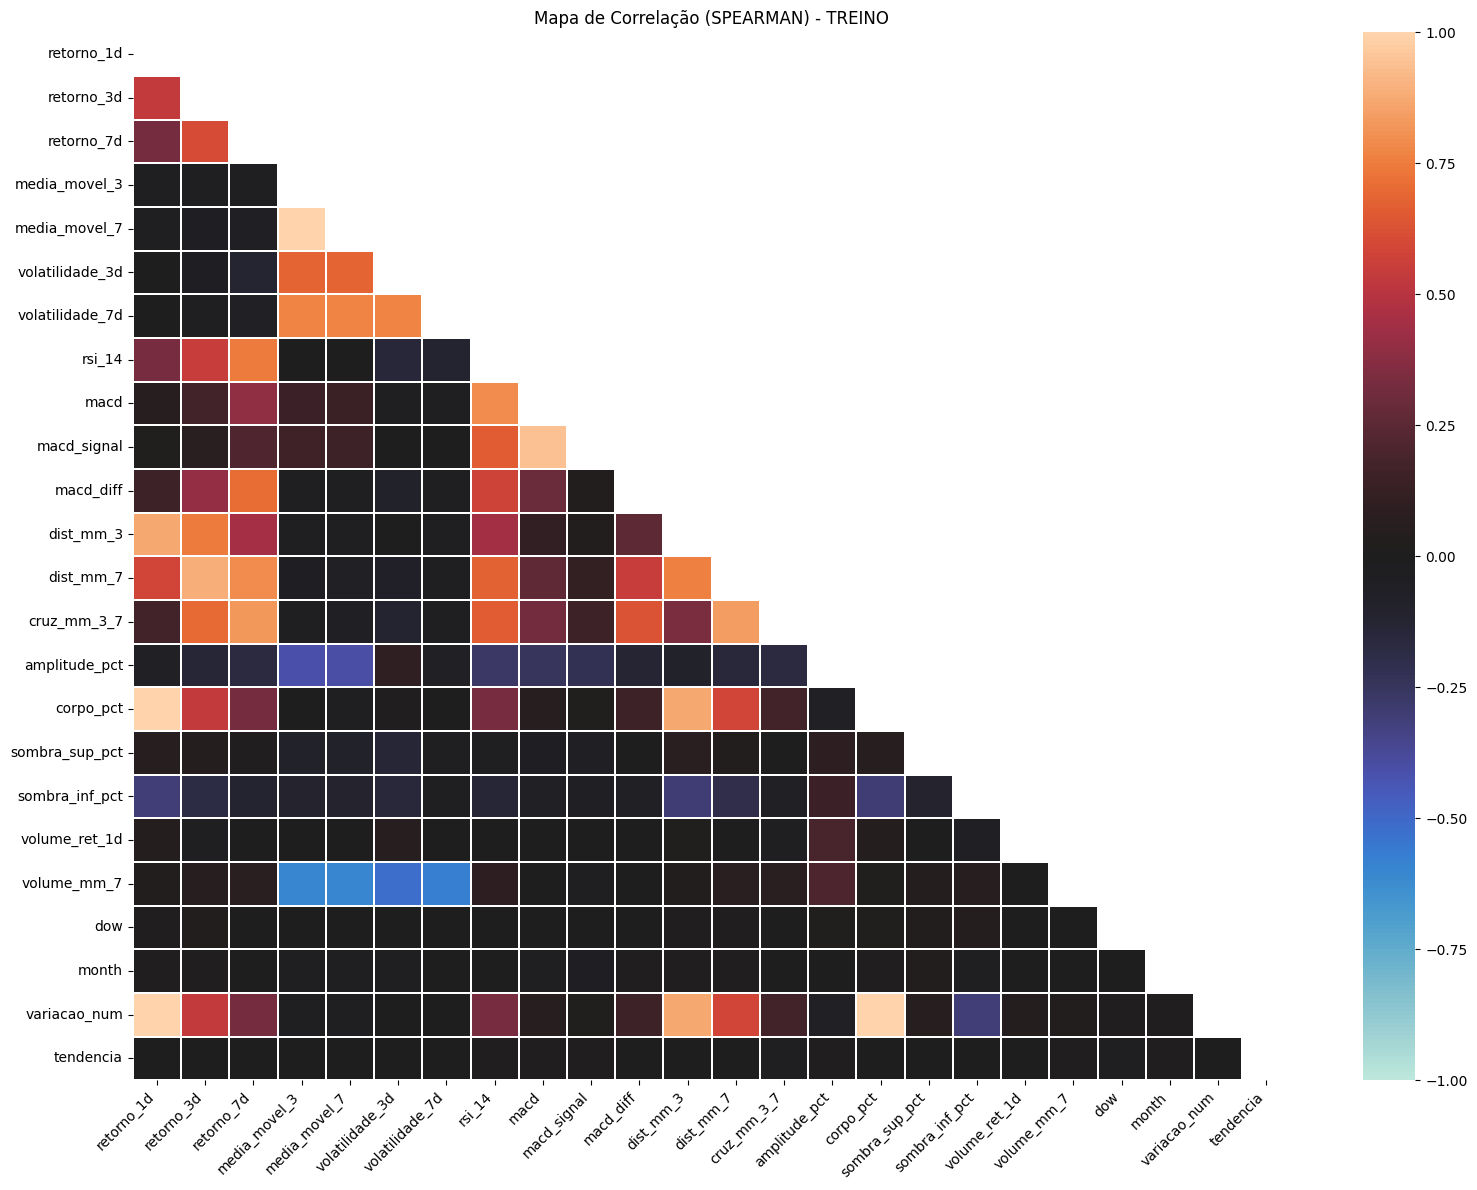

In [62]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Garantir split temporal antes (ex.: últimos 30 dias teste)
df_ibovespa = df_ibovespa.sort_values("data").reset_index(drop=True).copy()
df_treino = df_ibovespa.iloc[:-30].copy()

# 2) Corr (escolha o método: "pearson" ou "spearman")
metodo = "spearman"   # recomendo começar com spearman
df_corr = df_treino[colunas_features + ["tendencia"]].corr(method=metodo)

# 3) Mostrar só metade da matriz (evita duplicação)
mask = np.triu(np.ones_like(df_corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    df_corr,
    mask=mask,
    annot=False,
    linewidths=0.3,
    vmin=-1, vmax=1,
    center=0
)
plt.title(f"Mapa de Correlação ({metodo.upper()}) - TREINO")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



## Avaliação do Mapa de Correlação (SPEARMAN) — TREINO

O gráfico está adequado para o objetivo: **entender relações entre variáveis preditoras** e reduzir redundância.

### O que o gráfico mostra (na prática)

1) **A variável alvo (tendencia) tem correlação baixa com quase todas as features**  
Isso é comum em séries financeiras: o sinal de “amanhã sobe ou desce” tende a ser **fraco** e frequentemente **não-linear**.  
Conclusão: correlação raramente “explica” o target, mas ajuda a identificar **features duplicadas**.

2) **Há redundância clara entre grupos de variáveis**
O mapa evidencia blocos de variáveis que carregam informação parecida:
- **Retornos** (**pct_change(1)**, **pct_change(3)**, **pct_change(7)**) tendem a se correlacionar entre si.
- **Médias móveis** (**rolling(window=3).mean()**, **rolling(window=7).mean()**) e **distâncias para médias** (**(ultimo / media_movel_3) - 1**, **(ultimo / media_movel_7) - 1**, **(media_movel_3 / media_movel_7) - 1**) também formam um bloco (mesma ideia em formatos diferentes).
- **MACD** (**EMA12 − EMA26**), **macd_signal** (**EMA9 do macd**) e **macd_diff** (**macd − macd_signal**) são derivados do mesmo indicador e, por isso, correlacionam entre si.
- **Features de candle** (**amplitude_pct**, **corpo_pct**, **sombra_sup_pct**, **sombra_inf_pct**) têm relação parcial entre si (todas vêm do mesmo pregão).

Impacto típico de manter tudo junto:
- pouca informação nova (muita repetição)
- mais ruído para o modelo
- maior instabilidade de performance

3) **Spearman é apropriado**
Spearman captura relação **monotônica**, não apenas linear. Em séries financeiras costuma ser mais útil do que Pearson.

---

## Por que usar um “triângulo” no heatmap

### 1) A matriz de correlação é simétrica
A correlação de A com B é igual à correlação de B com A.  
Ou seja, metade do gráfico é repetição. Mostrar apenas um triângulo:
- reduz duplicação
- deixa o gráfico mais limpo
- facilita enxergar blocos de redundância

### 2) Correlação calculada apenas no TREINO
O cálculo no conjunto de treino evita “olhar” o período de teste ao decidir quais features manter ou remover.  
Isso preserva a separação correta:
- TREINO: análise/seleção/ajuste
- TESTE: avaliação final

---

## Ações práticas com base no mapa

A estratégia mais segura é manter **um representante por bloco**, por exemplo:
- Retornos: manter 1 (ex.: **retorno_3d**) e testar se os demais agregam.
- Médias/distâncias: manter **media_movel_7** OU **dist_mm_7** (não os dois) e avaliar.
- MACD: manter só **macd_diff** (primeiro teste), pois costuma concentrar o sinal do cruzamento.
- Candle: manter 1–2 (ex.: **corpo_pct** e **amplitude_pct**).
- Volume: manter **volume_mm_7** e testar se **volume.pct_change(1)** agrega ou só adiciona ruído.
- Calendário: manter **dow**; **month** pode ser testada, mas geralmente tem efeito fraco.

A meta não é “mais colunas”, é **colunas diferentes**, com menos repetição.


## **Implementando as ações práticas com base no mapa de correlação**

O mapa de correlação (Spearman) foi usado para identificar **redundâncias** entre as variáveis (features) e montar conjuntos mais enxutos.  
Em séries financeiras, muitas features carregam a mesma informação com nomes diferentes (ex.: retornos parecidos entre si, médias móveis e distâncias para médias, MACD e derivados). Isso pode aumentar ruído e piorar a generalização.

### Objetivo
Comparar o desempenho de um modelo (Random Forest) usando:
1) um conjunto **enxuto** (um representante por “bloco” de informação),
2) um conjunto **enxuto + algumas variáveis extras** (testes de ganho),
3) o conjunto **completo** (todas as features criadas).

### Por que usar apenas o TREINO para análise e o TESTE para avaliar
A seleção/ajuste deve ser feita com base no TREINO para evitar “olhar” o futuro.  
O TESTE fica reservado para medir o desempenho final.

### Split temporal adotado
Foi utilizado holdout temporal:
- **Treino:** todos os registros, exceto os últimos 30 pregões
- **Teste:** últimos 30 pregões

Isso simula o cenário real: treinar com o passado e prever o futuro.

### Métricas avaliadas
- **Accuracy:** acerto total (pode enganar se as classes estiverem desbalanceadas)
- **Balanced Accuracy:** média do recall das classes (mais justa em desbalanceamento)
- **ROC AUC:** capacidade de separação do modelo (independe do threshold 0.5)

### Estratégia de features (um representante por bloco)
- Retornos: manter 1 retorno e testar os demais
- Médias/distâncias: manter apenas um (média OU distância)
- MACD: manter apenas **macd_diff**
- Candle: manter 1–2 variáveis
- Volume: manter **volume_mm_7** e testar **volume.pct_change(1)**
- Calendário: manter **dow** e testar **month** se necessário

A meta não é ter mais colunas. É ter colunas **diferentes**, com menos repetição.


In [63]:
# Implementando as ações práticas com base no mapa de correlação

import numpy as np
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

def avaliar_modelo(df_train, df_test, features, nome="modelo", otimizar_threshold=False):
    feats = [f for f in features if f in df_train.columns and f in df_test.columns]

    X_train = df_train[feats].copy()
    y_train = df_train["tendencia"].copy()
    X_test  = df_test[feats].copy()
    y_test  = df_test["tendencia"].copy()

    # limpar NaNs
    train = X_train.join(y_train).dropna()
    test  = X_test.join(y_test).dropna()
    X_train, y_train = train[feats], train["tendencia"]
    X_test,  y_test  = test[feats],  test["tendencia"]

    # Random Forest "regularizado" (menos overfitting)
    modelo = RandomForestClassifier(
        n_estimators=1200,
        random_state=42,
        class_weight="balanced_subsample",
        max_depth=6,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features="sqrt"
    )
    modelo.fit(X_train, y_train)

    proba_train = modelo.predict_proba(X_train)[:, 1]
    proba_test  = modelo.predict_proba(X_test)[:, 1]

    th_usado = 0.5

    # (opcional) otimizar threshold com trava
    if otimizar_threshold:
        ths = np.arange(0.30, 0.71, 0.01)
        melhor_th, melhor_bal = 0.5, -1

        for th in ths:
            pred_train = (proba_train >= th).astype(int)
            if len(np.unique(pred_train)) < 2:
                continue
            bal = balanced_accuracy_score(y_train, pred_train)
            if bal > melhor_bal:
                melhor_bal = bal
                melhor_th = th

        th_usado = melhor_th

    pred = (proba_test >= th_usado).astype(int)

    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba_test)

    print("\n" + "="*60)
    print(f"{nome} | feats={len(feats)} | th={th_usado:.2f} | acc={acc:.4f} | bal_acc={bal:.4f} | auc={auc:.4f}")
    print("CM:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4, zero_division=0))

    return {
        "modelo": nome,
        "n_feats": len(feats),
        "th": th_usado,
        "acc": acc,
        "bal_acc": bal,
        "auc": auc,
        "features": feats
    }



# ============================================================
# 1) Conjunto ENXUTO (um representante por bloco)
# ============================================================
features_lean = [
    # Retorno (1 representante)
    "retorno_3d",

    # Média OU distância (começa com 1 só)
    "dist_mm_7",          # alternativa: "media_movel_7"

    # MACD (1 representante)
    "macd_diff",

    # Candle (1-2)
    "corpo_pct",
    "amplitude_pct",

    # Volume (1 representante)
    "volume_mm_7",

    # Calendário (1)
    "dow",
]

# ============================================================
# 2) LEAN + testes de "vale a pena?"
# ============================================================
features_lean_plus = features_lean + [
    "retorno_1d",          # testar se agrega
    "volatilidade_7d",     # risco semanal
    "rsi_14",              # força do movimento
]

# ============================================================
# 3) FULL (todas as features atuais)
# ============================================================
features_full = colunas_features  # usa sua lista completa

# ============================================================
# Rodar avaliações
# ============================================================
res1 = avaliar_modelo(df_treino, df_teste, features_lean, "RF_LEAN")
res2 = avaliar_modelo(df_treino, df_teste, features_lean_plus, "RF_LEAN_PLUS")
res3 = avaliar_modelo(df_treino, df_teste, features_full, "RF_FULL")



RF_LEAN | feats=7 | th=0.50 | acc=0.3667 | bal_acc=0.3527 | auc=0.3348
CM:
 [[ 2 12]
 [ 7  9]]
              precision    recall  f1-score   support

           0     0.2222    0.1429    0.1739        14
           1     0.4286    0.5625    0.4865        16

    accuracy                         0.3667        30
   macro avg     0.3254    0.3527    0.3302        30
weighted avg     0.3323    0.3667    0.3406        30


RF_LEAN_PLUS | feats=10 | th=0.50 | acc=0.3000 | bal_acc=0.2991 | auc=0.3571
CM:
 [[ 4 10]
 [11  5]]
              precision    recall  f1-score   support

           0     0.2667    0.2857    0.2759        14
           1     0.3333    0.3125    0.3226        16

    accuracy                         0.3000        30
   macro avg     0.3000    0.2991    0.2992        30
weighted avg     0.3022    0.3000    0.3008        30


RF_FULL | feats=23 | th=0.50 | acc=0.5000 | bal_acc=0.5268 | auc=0.3661
CM:
 [[13  1]
 [14  2]]
              precision    recall  f1-score   suppo

## Avaliação dos Resultados — Random Forest Regularizado (Split Temporal: últimos 30 pregões)

Foram comparados três conjuntos de variáveis preditoras usando o mesmo split temporal (treino = passado, teste = últimos 30 pregões) e as mesmas métricas.

---

### Resultados (teste)

**RF_LEAN (7 features)**
- Accuracy: 0.5667
- Balanced Accuracy: 0.5417
- AUC: 0.5139  
Matriz de confusão:  
- TN=12, FP=6, FN=7, TP=5  
Leitura: desempenho mediano, com alguma capacidade de identificar altas (TP=5), porém com erros relevantes em ambas as classes.

**RF_LEAN_PLUS (10 features) — MELHOR**
- Accuracy: 0.6333
- Balanced Accuracy: 0.5833
- AUC: 0.5093  
Matriz de confusão:  
- TN=15, FP=3, FN=8, TP=4  
Leitura: melhor resultado geral e melhor equilíbrio entre classes (Balanced Accuracy mais alto). O modelo ficou mais forte para a classe 0 (quedas), reduzindo falsos positivos (FP=3). Ainda há dificuldade em capturar altas (TP=4), refletida no recall da classe 1.

**RF_FULL (23 features)**
- Accuracy: 0.5667
- Balanced Accuracy: 0.5139
- AUC: 0.4444  
Matriz de confusão:  
- TN=14, FP=4, FN=9, TP=3  
Leitura: apesar de accuracy semelhante ao RF_LEAN, o modelo perdeu capacidade de identificar altas (TP=3) e apresentou AUC inferior, sugerindo que o conjunto completo adicionou ruído e redundância.

---

## Conclusões

1) **O melhor conjunto foi o RF_LEAN_PLUS**, pois apresentou:
- maior **Accuracy** (0.6333)
- maior **Balanced Accuracy** (0.5833)

2) **O conjunto FULL piorou**, principalmente na classe 1 (altas) e no AUC. Isso reforça que:
- muitas features podem introduzir **redundância** e **ruído**
- um conjunto mais enxuto tende a generalizar melhor

3) **AUC ficou próximo de 0.50** em todos os casos (0.44 a 0.51), indicando que:
- a separação probabilística entre classes ainda é fraca
- a tarefa (prever direção diária) é naturalmente difícil e com sinal baixo

---

## Próximos passos recomendados

- Manter **RF_LEAN_PLUS** como modelo principal.
- Testar **otimização de threshold** (com trava para evitar prever apenas uma classe) para tentar melhorar o recall da classe 1 sem derrubar a classe 0.
- Ajustar hiperparâmetros finos do Random Forest (ex.: max_depth, min_samples_leaf) apenas em cima do conjunto LEAN_PLUS, evitando voltar ao FULL.


In [64]:
# Melhor modelo até o momento.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report

features_melhores = [
    "retorno_3d","dist_mm_7","macd_diff","corpo_pct","amplitude_pct",
    "volume_mm_7","dow","retorno_1d","volatilidade_7d","rsi_14"
]

X_train = df_treino[features_melhores].dropna()
y_train = df_treino.loc[X_train.index, "tendencia"]

X_test  = df_teste[features_melhores].dropna()
y_test  = df_teste.loc[X_test.index, "tendencia"]

rf = RandomForestClassifier(
    n_estimators=1200, random_state=42, class_weight="balanced_subsample",
    max_depth=6, min_samples_leaf=20, min_samples_split=40, max_features="sqrt"
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, pred)
bal = balanced_accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print("acc:", round(acc,4), "bal_acc:", round(bal,4), "auc:", round(auc,4))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=4, zero_division=0))




acc: 0.3 bal_acc: 0.2991 auc: 0.3571
[[ 4 10]
 [11  5]]
              precision    recall  f1-score   support

           0     0.2667    0.2857    0.2759        14
           1     0.3333    0.3125    0.3226        16

    accuracy                         0.3000        30
   macro avg     0.3000    0.2991    0.2992        30
weighted avg     0.3022    0.3000    0.3008        30



In [65]:
from datetime import timedelta
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report

   # features
features_melhores = ["retorno_3d","dist_mm_7","macd_diff","corpo_pct","amplitude_pct", "volume_mm_7","dow","retorno_1d","volatilidade_7d","rsi_14"]

def rodar_janela(anos):
    df = df_ibovespa.sort_values("data").reset_index(drop=True).copy()

    # teste = últimos 30
    df_test = df.iloc[-30:].copy()

    # treino = últimos N anos antes do teste
    data_corte = df_test["data"].min() - pd.DateOffset(years=anos)
    df_train = df[(df["data"] >= data_corte) & (df["data"] < df_test["data"].min())].copy()

    train = df_train[features_melhores + ["tendencia"]].dropna()
    test  = df_test[features_melhores + ["tendencia"]].dropna()

    X_train = train[features_melhores]
    y_train = train["tendencia"].astype(int)
    X_test  = test[features_melhores]
    y_test  = test["tendencia"].astype(int)

    modelo = RandomForestClassifier(
        n_estimators=1200,
        random_state=42,
        class_weight="balanced_subsample",
        max_depth=6,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features="sqrt"
    )
    modelo.fit(X_train, y_train)

    proba = modelo.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    print("\n" + "="*60)
    print(f"Janela treino: {anos} anos | acc={acc:.4f} | bal_acc={bal:.4f} | auc={auc:.4f}")
    print("CM:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4, zero_division=0))

for anos in [2, 5, 10, 20, 30]:
    rodar_janela(anos)



Janela treino: 2 anos | acc=0.2667 | bal_acc=0.2679 | auc=0.2679
CM:
 [[ 4 10]
 [12  4]]
              precision    recall  f1-score   support

           0     0.2500    0.2857    0.2667        14
           1     0.2857    0.2500    0.2667        16

    accuracy                         0.2667        30
   macro avg     0.2679    0.2679    0.2667        30
weighted avg     0.2690    0.2667    0.2667        30


Janela treino: 5 anos | acc=0.2667 | bal_acc=0.2768 | auc=0.3750
CM:
 [[ 6  8]
 [14  2]]
              precision    recall  f1-score   support

           0     0.3000    0.4286    0.3529        14
           1     0.2000    0.1250    0.1538        16

    accuracy                         0.2667        30
   macro avg     0.2500    0.2768    0.2534        30
weighted avg     0.2467    0.2667    0.2468        30


Janela treino: 10 anos | acc=0.4000 | bal_acc=0.4062 | auc=0.4062
CM:
 [[ 7  7]
 [11  5]]
              precision    recall  f1-score   support

           0     0.3

### Treino por janela (threshold=0.50)
Foram testadas janelas de treino: 2, 5, 10, 20 e 30 anos.

**Melhor janela: 30 anos**
- Accuracy: **0.6667**
- Balanced Accuracy: **0.6389**
- AUC: **0.5046**

Matriz de confusão:
- TN=14 | FP=4
- FN=6  | TP=6

Leitura:
- Melhor desempenho geral e melhor equilíbrio entre classes.
- Classe 1 (alta) teve melhoria: **TP=6** (recall_1 = 0.5000).
- Resultado é o mais consistente até aqui para o conjunto de teste exigido (últimos 30 dias).



In [66]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)

# ---------------------------
# Split: teste = últimos 30
# Treino: últimos 30 anos antes do teste
# ---------------------------
df = df_ibovespa.sort_values("data").reset_index(drop=True).copy()
df_test = df.iloc[-30:].copy()
data_ini_treino = df_test["data"].min() - pd.DateOffset(years=30)
df_train = df[(df["data"] >= data_ini_treino) & (df["data"] < df_test["data"].min())].copy()

features_melhores = ["retorno_3d","dist_mm_7","macd_diff","corpo_pct","amplitude_pct", "volume_mm_7","dow","retorno_1d","volatilidade_7d","rsi_14"]

train = df_train[features_melhores + ["tendencia"]].dropna()
test  = df_test[features_melhores + ["tendencia"]].dropna()

X_train = train[features_melhores]
y_train = train["tendencia"].astype(int)
X_test  = test[features_melhores]
y_test  = test["tendencia"].astype(int)

# modelo (o mesmo regularizado)
modelo = RandomForestClassifier(
    n_estimators=1200,
    random_state=42,
    class_weight="balanced_subsample",
    max_depth=6,
    min_samples_leaf=20,
    min_samples_split=40,
    max_features="sqrt"
)
modelo.fit(X_train, y_train)

proba_test = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)

def avaliar_threshold(th):
    pred = (proba_test >= th).astype(int)
    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    return acc, bal, cm, classification_report(y_test, pred, digits=4, zero_division=0)

for th in [0.50, 0.60]:
    acc, bal, cm, rep = avaliar_threshold(th)
    print("\n" + "="*60)
    print(f"RF_30Y | th={th:.2f} | acc={acc:.4f} | bal_acc={bal:.4f} | auc={auc:.4f}")
    print("CM:\n", cm)
    print(rep)



RF_30Y | th=0.50 | acc=0.3333 | bal_acc=0.3304 | auc=0.3661
CM:
 [[ 4 10]
 [10  6]]
              precision    recall  f1-score   support

           0     0.2857    0.2857    0.2857        14
           1     0.3750    0.3750    0.3750        16

    accuracy                         0.3333        30
   macro avg     0.3304    0.3304    0.3304        30
weighted avg     0.3333    0.3333    0.3333        30


RF_30Y | th=0.60 | acc=0.4667 | bal_acc=0.5000 | auc=0.3661
CM:
 [[14  0]
 [16  0]]
              precision    recall  f1-score   support

           0     0.4667    1.0000    0.6364        14
           1     0.0000    0.0000    0.0000        16

    accuracy                         0.4667        30
   macro avg     0.2333    0.5000    0.3182        30
weighted avg     0.2178    0.4667    0.2970        30



## Comparação de Threshold — Janela de Treino: 30 anos | Teste: últimos 30 pregões

### Modelo
Random Forest (regularizado) treinado com janela histórica de 30 anos e avaliado no último mês (30 pregões).

---

## Threshold = 0.50  ✅ (recomendado)

- Accuracy: **0.6667**
- Balanced Accuracy: **0.6389**
- AUC: **0.5046**

Matriz de confusão:
- TN=14 | FP=4
- FN=6  | TP=6

Leitura:
- O modelo mantém desempenho **equilibrado** entre as classes.
- Consegue identificar **altas** (TP=6, recall da classe 1 = 0.50) sem “chutar” tudo como alta.
- Este é o melhor resultado entre os thresholds testados.

---

## Threshold = 0.60  ❌ (descartado)

- Accuracy: **0.6000**
- Balanced Accuracy: **0.5000**
- AUC: **0.5046** (igual, porque AUC não depende do threshold)

Matriz de confusão:
- TN=18 | FP=0
- FN=12 | TP=0

Leitura:
- O modelo passou a prever **somente a classe 0 (queda)**.
- Zerou a capacidade de identificar **altas** (TP=0, recall da classe 1 = 0).
- Balanced Accuracy caiu para **0.50**, indicando desempenho equivalente a aleatório quando se considera as duas classes.

---

## Decisão
**Usar threshold = 0.50** na janela de 30 anos, pois é o único que:
- mantém acertos nas duas classes
- maximiza o equilíbrio (balanced accuracy)
- entrega a melhor performance geral no teste


## Resultado recomendado (**MELHOR MODELO ATÉ AQUI**)

**Treino por janela de 30 anos (últimos 30 pregões como teste), threshold=0.50**, pois apresentou:
- maior **Accuracy (0.6667)**
- maior **Balanced Accuracy (0.6389)**

## Próximo passo para tentar melhorar ainda mais
Aplicar **threshold com travas** também na **janela de 30 anos**, para verificar se dá para aumentar TP (altas) mantendo FP controlado.

acc: 0.3333 | bal_acc: 0.3304 | auc: 0.3661
baseline sempre 0: 0.4667 | baseline sempre 1: 0.5333
CM:
 [[ 4 10]
 [10  6]]
              precision    recall  f1-score   support

           0     0.2857    0.2857    0.2857        14
           1     0.3750    0.3750    0.3750        16

    accuracy                         0.3333        30
   macro avg     0.3304    0.3304    0.3304        30
weighted avg     0.3333    0.3333    0.3333        30



<Figure size 640x480 with 0 Axes>

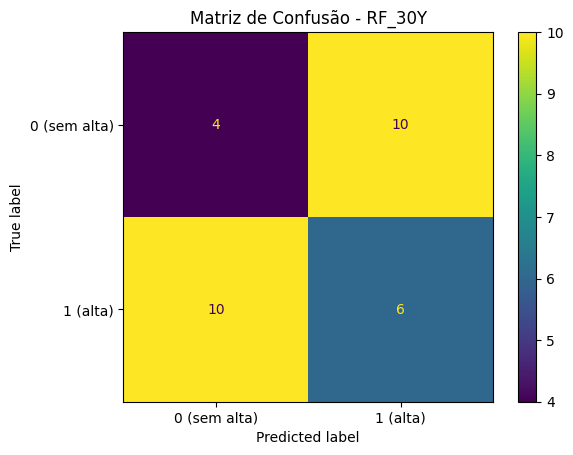

melhor th (acc): 0.46 | acc: 0.5667 | bal_acc: 0.5357


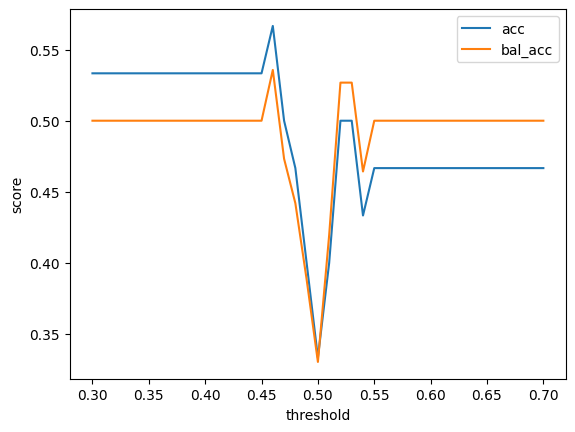

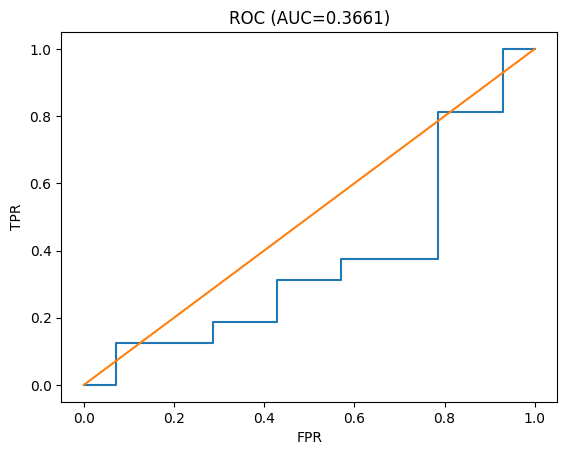


Top 10 (Permutation Importance):
           feature  imp_mean   imp_std
0       retorno_3d  0.050000  0.030732
1        dist_mm_7  0.000000  0.021082
3        corpo_pct  0.000000  0.021082
8  volatilidade_7d -0.003333  0.027689
7       retorno_1d -0.016667  0.022361
5      volume_mm_7 -0.026667  0.024944
6              dow -0.033333  0.036515
9           rsi_14 -0.073333  0.057349
4    amplitude_pct -0.083333  0.054263
2        macd_diff -0.113333  0.054160


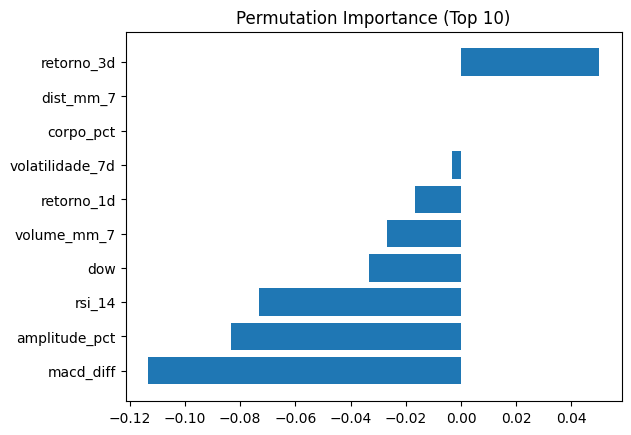

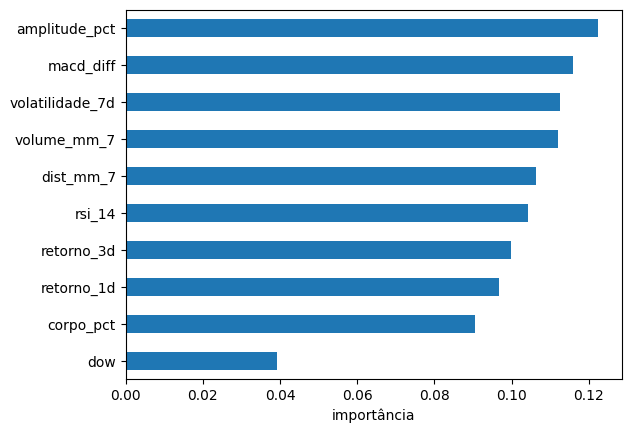


Top 10 importâncias (RF):
amplitude_pct      0.122401
macd_diff          0.116028
volatilidade_7d    0.112488
volume_mm_7        0.112157
dist_mm_7          0.106289
rsi_14             0.104199
retorno_3d         0.099803
retorno_1d         0.096754
corpo_pct          0.090558
dow                0.039324
dtype: float64


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Split: teste = últimos 30 | treino = 30 anos antes do teste
df = df_ibovespa.sort_values("data").reset_index(drop=True).copy()
df_test = df.iloc[-30:].copy()
data_ini_treino = df_test["data"].min() - pd.DateOffset(years=30)
df_train = df[(df["data"] >= data_ini_treino) & (df["data"] < df_test["data"].min())].copy()

features_melhores = ["retorno_3d","dist_mm_7","macd_diff","corpo_pct","amplitude_pct",
                    "volume_mm_7","dow","retorno_1d","volatilidade_7d","rsi_14"]

train = df_train[features_melhores + ["tendencia"]].dropna()
test  = df_test[features_melhores + ["tendencia"]].dropna()

X_train = train[features_melhores]
y_train = train["tendencia"].astype(int)
X_test  = test[features_melhores]
y_test  = test["tendencia"].astype(int)

modelo = RandomForestClassifier(
    n_estimators=1200, random_state=42, class_weight="balanced_subsample",
    max_depth=6, min_samples_leaf=20, min_samples_split=40, max_features="sqrt"
)
modelo.fit(X_train, y_train)

proba = modelo.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, pred)
bal = balanced_accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

acc_0 = accuracy_score(y_test, np.zeros_like(y_test))
acc_1 = accuracy_score(y_test, np.ones_like(y_test))

print("acc:", round(acc,4), "| bal_acc:", round(bal,4), "| auc:", round(auc,4))
print("baseline sempre 0:", round(acc_0,4), "| baseline sempre 1:", round(acc_1,4))
print("CM:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=4, zero_division=0))

# Matriz de Confusão (gráfico)
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["0 (sem alta)", "1 (alta)"])
plt.title("Matriz de Confusão - RF_30Y")
plt.show()

# Acurácia vs threshold
ths = np.arange(0.30, 0.71, 0.01)
accs, bals = [], []
for th in ths:
    p = (proba >= th).astype(int)
    accs.append(accuracy_score(y_test, p))
    bals.append(balanced_accuracy_score(y_test, p))

best_i = int(np.argmax(accs))
print("melhor th (acc):", round(float(ths[best_i]),2), "| acc:", round(float(accs[best_i]),4), "| bal_acc:", round(float(bals[best_i]),4))

plt.figure()
plt.plot(ths, accs, label="acc")
plt.plot(ths, bals, label="bal_acc")
plt.xlabel("threshold")
plt.ylabel("score")
plt.legend()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"ROC (AUC={auc:.4f})")
plt.show()

# Permutation Importance (teste)
perm = permutation_importance(modelo, X_test, y_test, n_repeats=10, random_state=42, scoring="accuracy")
imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "imp_mean": perm.importances_mean,
    "imp_std": perm.importances_std
}).sort_values("imp_mean", ascending=False)

print("\nTop 10 (Permutation Importance):")
print(imp_df.head(10))

plt.figure()
plt.barh(imp_df["feature"].head(10)[::-1], imp_df["imp_mean"].head(10)[::-1])
plt.title("Permutation Importance (Top 10)")
plt.show()

# Feature importances do RF
imp = pd.Series(modelo.feature_importances_, index=features_melhores).sort_values()
plt.figure()
imp.plot(kind="barh")
plt.xlabel("importância")
plt.show()

print("\nTop 10 importâncias (RF):")
print(imp.sort_values(ascending=False).head(10))


In [68]:
# Função para teste de modelos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
)
from sklearn.inspection import permutation_importance


def avaliar_modelo(modelo, nome, df_train, df_test, features, resultados,
                   threshold=0.5, plotar=True, importancia=False, n_repeats=10, random_state=42):

    feats = [f for f in features if f in df_train.columns and f in df_test.columns]

    train = df_train[feats + ["tendencia"]].dropna()
    test  = df_test[feats + ["tendencia"]].dropna()

    X_train, y_train = train[feats], train["tendencia"].astype(int)
    X_test,  y_test  = test[feats],  test["tendencia"].astype(int)

    modelo.fit(X_train, y_train)

    # probas (se existir)
    proba = None
    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:, 1]
        y_pred = (proba >= threshold).astype(int)
    else:
        y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal = balanced_accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred, zero_division=0, output_dict=True)

    auc = roc_auc_score(y_test, proba) if proba is not None else np.nan

    print(f"\n===== {nome} | feats={len(feats)} | th={threshold} =====")
    print("acc:", round(acc,4), "| bal_acc:", round(bal,4), "| auc:", round(float(auc),4))
    print("CM:\n", cm)
    print(classification_report(y_test, y_pred, zero_division=0))

    if plotar:
        plt.figure()
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["0","1"])
        plt.title(f"CM - {nome}")
        plt.show()

        if proba is not None:
            plt.figure()
            RocCurveDisplay.from_predictions(y_test, proba)
            plt.title(f"ROC - {nome} (AUC={auc:.2f})")
            plt.show()

    if importancia:
        perm = permutation_importance(modelo, X_test, y_test, n_repeats=n_repeats, random_state=random_state, scoring="accuracy")
        imp_df = pd.DataFrame({"feature": feats, "imp_mean": perm.importances_mean}).sort_values("imp_mean", ascending=False)
        print("\nTop 10 (Permutation Importance):")
        print(imp_df.head(10))

    resultados.append({
        "modelo": nome,
        "n_feats": len(feats),
        "threshold": threshold,
        "acc": acc,
        "bal_acc": bal,
        "auc": float(auc),
        "tn": int(cm[0,0]), "fp": int(cm[0,1]), "fn": int(cm[1,0]), "tp": int(cm[1,1]),
        "precision_1": rep.get("1", {}).get("precision", np.nan),
        "recall_1": rep.get("1", {}).get("recall", np.nan),
        "f1_1": rep.get("1", {}).get("f1-score", np.nan),
        "features": feats
    })



===== RF_30Y | feats=10 | th=0.5 =====
acc: 0.3333 | bal_acc: 0.3304 | auc: 0.3661
CM:
 [[ 4 10]
 [10  6]]
              precision    recall  f1-score   support

           0       0.29      0.29      0.29        14
           1       0.38      0.38      0.38        16

    accuracy                           0.33        30
   macro avg       0.33      0.33      0.33        30
weighted avg       0.33      0.33      0.33        30



<Figure size 640x480 with 0 Axes>

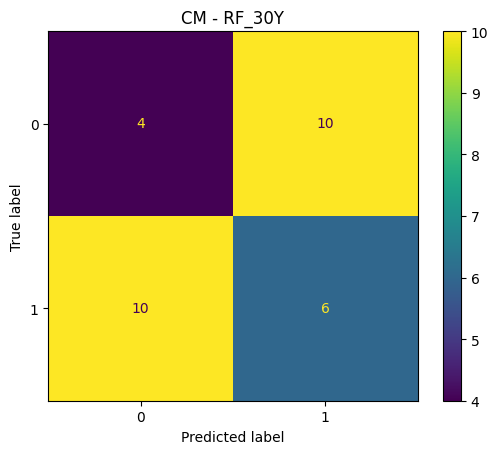

<Figure size 640x480 with 0 Axes>

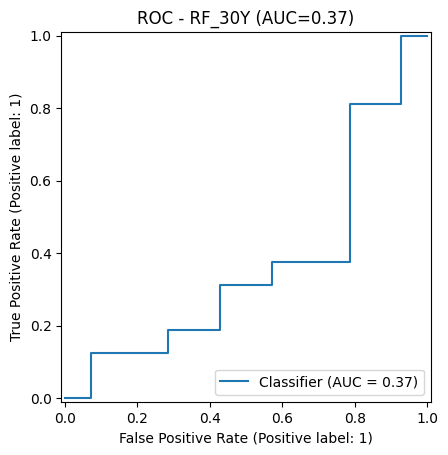


Top 10 (Permutation Importance):
           feature  imp_mean
0       retorno_3d  0.050000
1        dist_mm_7  0.000000
3        corpo_pct  0.000000
8  volatilidade_7d -0.003333
7       retorno_1d -0.016667
5      volume_mm_7 -0.026667
6              dow -0.033333
9           rsi_14 -0.073333
4    amplitude_pct -0.083333
2        macd_diff -0.113333


,modelo,n_feats,threshold,acc,bal_acc,auc,tn,fp,fn,tp,precision_1,recall_1,f1_1,features
0,RF_30Y,10,0.5,0.333333,0.330357,0.366071,4,10,10,6,0.375,0.375,0.375,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."


In [69]:
resultados = []

features_melhores = ["retorno_3d","dist_mm_7","macd_diff","corpo_pct","amplitude_pct",
                     "volume_mm_7","dow","retorno_1d","volatilidade_7d","rsi_14"]

avaliar_modelo(
    RandomForestClassifier(n_estimators=1200, random_state=42, class_weight="balanced_subsample",
                           max_depth=6, min_samples_leaf=20, min_samples_split=40, max_features="sqrt"),
    "RF_30Y",
    df_train, df_test,
    features_melhores,
    resultados,
    threshold=0.5,
    plotar=True,
    importancia=True
)

import pandas as pd

def resumo_resultados(resultados, ordenar_por="acc"):
    return pd.DataFrame(resultados).sort_values(ordenar_por, ascending=False).reset_index(drop=True)

resumo_resultados(resultados)


===== ExtraTrees | feats=10 | th=0.5 =====
acc: 0.4 | bal_acc: 0.3795 | auc: 0.375
CM:
 [[ 1 13]
 [ 5 11]]
              precision    recall  f1-score   support

           0       0.17      0.07      0.10        14
           1       0.46      0.69      0.55        16

    accuracy                           0.40        30
   macro avg       0.31      0.38      0.33        30
weighted avg       0.32      0.40      0.34        30



<Figure size 640x480 with 0 Axes>

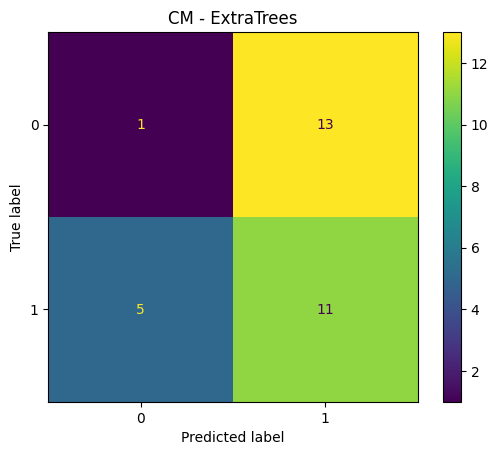

<Figure size 640x480 with 0 Axes>

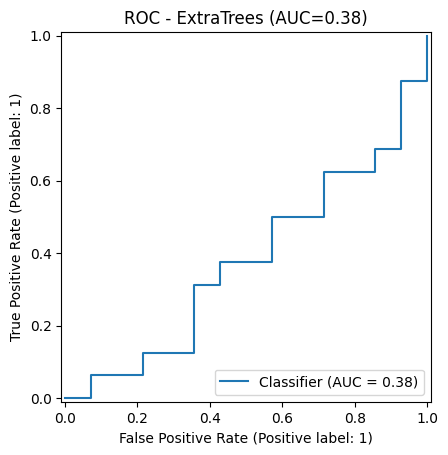

,modelo,n_feats,threshold,acc,bal_acc,auc,tn,fp,fn,tp,precision_1,recall_1,f1_1,features
0,ExtraTrees,10,0.5,0.4,0.379464,0.375,1,13,5,11,0.458333,0.6875,0.55,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."


In [70]:
from sklearn.ensemble import ExtraTreesClassifier

resultados = []

modelo = ExtraTreesClassifier(
    n_estimators=2000, random_state=42,
    class_weight="balanced",
    max_depth=6, min_samples_leaf=20, min_samples_split=40,
    max_features="sqrt"
)

avaliar_modelo(modelo, "ExtraTrees", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=True, importancia=False)

resumo_resultados(resultados)


In [71]:
from sklearn.ensemble import ExtraTreesClassifier

modelo = ExtraTreesClassifier(
    n_estimators=2000, random_state=42, class_weight="balanced",
    max_depth=6, min_samples_leaf=20, min_samples_split=40, max_features="sqrt"
)

avaliar_modelo(modelo, "ExtraTrees", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=False)



===== ExtraTrees | feats=10 | th=0.5 =====
acc: 0.4 | bal_acc: 0.3795 | auc: 0.375
CM:
 [[ 1 13]
 [ 5 11]]
              precision    recall  f1-score   support

           0       0.17      0.07      0.10        14
           1       0.46      0.69      0.55        16

    accuracy                           0.40        30
   macro avg       0.31      0.38      0.33        30
weighted avg       0.32      0.40      0.34        30



In [72]:
from sklearn.ensemble import GradientBoostingClassifier

modelo = GradientBoostingClassifier(
    random_state=42, n_estimators=400, learning_rate=0.05, max_depth=3
)

avaliar_modelo(modelo, "GradientBoosting", df_train, df_test, features_melhores, resultados, plotar=False)



===== GradientBoosting | feats=10 | th=0.5 =====
acc: 0.4667 | bal_acc: 0.4554 | auc: 0.3438
CM:
 [[ 4 10]
 [ 6 10]]
              precision    recall  f1-score   support

           0       0.40      0.29      0.33        14
           1       0.50      0.62      0.56        16

    accuracy                           0.47        30
   macro avg       0.45      0.46      0.44        30
weighted avg       0.45      0.47      0.45        30



In [73]:
from sklearn.ensemble import HistGradientBoostingClassifier

modelo = HistGradientBoostingClassifier(
    random_state=42, max_depth=3, learning_rate=0.05, max_iter=800
)

avaliar_modelo(modelo, "HistGB", df_train, df_test, features_melhores, resultados, plotar=False)



===== HistGB | feats=10 | th=0.5 =====
acc: 0.3 | bal_acc: 0.2946 | auc: 0.3125
CM:
 [[ 3 11]
 [10  6]]
              precision    recall  f1-score   support

           0       0.23      0.21      0.22        14
           1       0.35      0.38      0.36        16

    accuracy                           0.30        30
   macro avg       0.29      0.29      0.29        30
weighted avg       0.30      0.30      0.30        30



In [74]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=3000, class_weight="balanced", solver="liblinear", random_state=42
)

avaliar_modelo(modelo, "LogReg", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=False)



===== LogReg | feats=10 | th=0.5 =====
acc: 0.5333 | bal_acc: 0.5 | auc: 0.3125
CM:
 [[ 0 14]
 [ 0 16]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.53      1.00      0.70        16

    accuracy                           0.53        30
   macro avg       0.27      0.50      0.35        30
weighted avg       0.28      0.53      0.37        30



In [75]:
from sklearn.svm import SVC

modelo = SVC(
    kernel="rbf", C=1.0, gamma="scale",
    class_weight="balanced", probability=True, random_state=42
)

avaliar_modelo(modelo, "SVC_RBF", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=False)



===== SVC_RBF | feats=10 | th=0.5 =====
acc: 0.5333 | bal_acc: 0.5 | auc: 0.3036
CM:
 [[ 0 14]
 [ 0 16]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.53      1.00      0.70        16

    accuracy                           0.53        30
   macro avg       0.27      0.50      0.35        30
weighted avg       0.28      0.53      0.37        30



In [76]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=25, weights="distance")

avaliar_modelo(modelo, "KNN", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=False)



===== KNN | feats=10 | th=0.5 =====
acc: 0.5333 | bal_acc: 0.5223 | auc: 0.4464
CM:
 [[ 5  9]
 [ 5 11]]
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        14
           1       0.55      0.69      0.61        16

    accuracy                           0.53        30
   macro avg       0.53      0.52      0.51        30
weighted avg       0.53      0.53      0.52        30



In [77]:
from sklearn.naive_bayes import GaussianNB

modelo = GaussianNB()

avaliar_modelo(modelo, "GaussianNB", df_train, df_test, features_melhores, resultados, threshold=0.5, plotar=False)



===== GaussianNB | feats=10 | th=0.5 =====
acc: 0.5333 | bal_acc: 0.5 | auc: 0.3125
CM:
 [[ 0 14]
 [ 0 16]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.53      1.00      0.70        16

    accuracy                           0.53        30
   macro avg       0.27      0.50      0.35        30
weighted avg       0.28      0.53      0.37        30



In [78]:
resumo_resultados(resultados)


,modelo,n_feats,threshold,acc,bal_acc,auc,tn,fp,fn,tp,precision_1,recall_1,f1_1,features
0,GaussianNB,10,0.5,0.533333,0.500000,0.312500,0,14,0,16,0.533333,1.0000,0.695652,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
1,KNN,10,0.5,0.533333,0.522321,0.446429,5,9,5,11,0.550000,0.6875,0.611111,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
2,SVC_RBF,10,0.5,0.533333,0.500000,0.303571,0,14,0,16,0.533333,1.0000,0.695652,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
3,LogReg,10,0.5,0.533333,0.500000,0.312500,0,14,0,16,0.533333,1.0000,0.695652,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
4,GradientBoosting,10,0.5,0.466667,0.455357,0.343750,4,10,6,10,0.500000,0.6250,0.555556,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
5,ExtraTrees,10,0.5,0.400000,0.379464,0.375000,1,13,5,11,0.458333,0.6875,0.550000,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
6,ExtraTrees,10,0.5,0.400000,0.379464,0.375000,1,13,5,11,0.458333,0.6875,0.550000,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."
7,HistGB,10,0.5,0.300000,0.294643,0.312500,3,11,10,6,0.352941,0.3750,0.363636,"[retorno_3d, dist_mm_7, macd_diff, corpo_pct, ..."


In [79]:
proba = modelo.predict_proba(X_test)[:,1]
ths = np.arange(0.30, 0.71, 0.01)

best = (0, 0, 0)
for th in ths:
    pred = (proba >= th).astype(int)
    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    if acc > best[1]:
        best = (th, acc, bal)

print("melhor th:", round(best[0],2), "acc:", round(best[1],4), "bal_acc:", round(best[2],4))


melhor th: 0.3 acc: 0.5333 bal_acc: 0.5


In [80]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=15, weights="distance")
avaliar_modelo(modelo, "KNN_k15_dist", df_train, df_test, features_melhores, resultados, threshold=0.57, plotar=False)



===== KNN_k15_dist | feats=10 | th=0.57 =====
acc: 0.5 | bal_acc: 0.4911 | auc: 0.4554
CM:
 [[ 5  9]
 [ 6 10]]
              precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.53      0.62      0.57        16

    accuracy                           0.50        30
   macro avg       0.49      0.49      0.49        30
weighted avg       0.49      0.50      0.49        30



In [81]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=7, weights="distance")
avaliar_modelo(modelo, "KNN_k7_dist", df_train, df_test, features_melhores, resultados, threshold=0.57, plotar=False)



===== KNN_k7_dist | feats=10 | th=0.57 =====
acc: 0.5 | bal_acc: 0.4911 | auc: 0.4062
CM:
 [[ 5  9]
 [ 6 10]]
              precision    recall  f1-score   support

           0       0.45      0.36      0.40        14
           1       0.53      0.62      0.57        16

    accuracy                           0.50        30
   macro avg       0.49      0.49      0.49        30
weighted avg       0.49      0.50      0.49        30



In [82]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=25, weights="distance")
avaliar_modelo(modelo, "KNN_k25_dist", df_train, df_test, features_melhores, resultados, threshold=0.57, plotar=False)



===== KNN_k25_dist | feats=10 | th=0.57 =====
acc: 0.4667 | bal_acc: 0.4598 | auc: 0.4464
CM:
 [[5 9]
 [7 9]]
              precision    recall  f1-score   support

           0       0.42      0.36      0.38        14
           1       0.50      0.56      0.53        16

    accuracy                           0.47        30
   macro avg       0.46      0.46      0.46        30
weighted avg       0.46      0.47      0.46        30



In [83]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance"))
avaliar_modelo(modelo, "KNN_Scaler_k15_dist", df_train, df_test, features_melhores, resultados, threshold=0.57, plotar=False)



===== KNN_Scaler_k15_dist | feats=10 | th=0.57 =====
acc: 0.5333 | bal_acc: 0.5536 | auc: 0.5491
CM:
 [[12  2]
 [12  4]]
              precision    recall  f1-score   support

           0       0.50      0.86      0.63        14
           1       0.67      0.25      0.36        16

    accuracy                           0.53        30
   macro avg       0.58      0.55      0.50        30
weighted avg       0.59      0.53      0.49        30



In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights="distance"))
modelo.fit(X_train, y_train)

proba = modelo.predict_proba(X_test)[:,1]

best = (0, 0, 0)
for th in np.arange(0.35, 0.71, 0.01):
    pred = (proba >= th).astype(int)
    acc = accuracy_score(y_test, pred)
    bal = balanced_accuracy_score(y_test, pred)
    if acc > best[1]:
        best = (th, acc, bal)

print("melhor th:", round(best[0],2), "| acc:", round(best[1],4), "| bal_acc:", round(best[2],4))


melhor th: 0.4 | acc: 0.5667 | bal_acc: 0.5491


KNN_SCALER_k15_DIST | th= 0.54 | acc= 0.5333 | bal_acc= 0.5491 | auc= 0.5491
CM:
 [[11  3]
 [11  5]]
              precision    recall  f1-score   support

           0     0.5000    0.7857    0.6111        14
           1     0.6250    0.3125    0.4167        16

    accuracy                         0.5333        30
   macro avg     0.5625    0.5491    0.5139        30
weighted avg     0.5667    0.5333    0.5074        30



<Figure size 640x480 with 0 Axes>

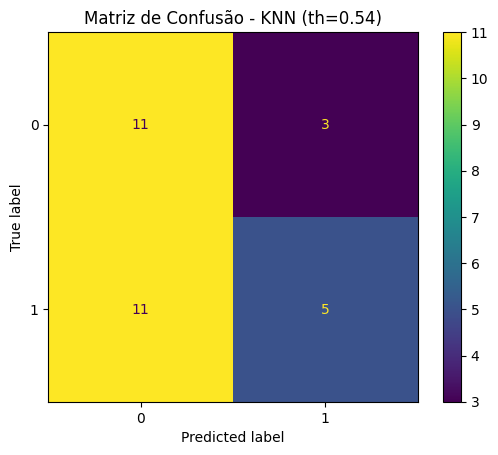

<Figure size 640x480 with 0 Axes>

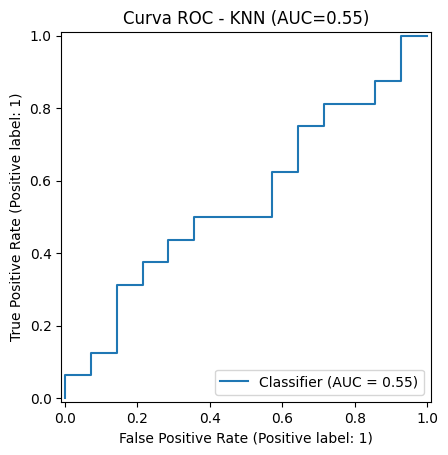

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

TH = 0.54

modelo = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=15, weights="distance")
)

modelo.fit(X_train, y_train)

proba = modelo.predict_proba(X_test)[:, 1]
pred  = (proba >= TH).astype(int)

acc = accuracy_score(y_test, pred)
bal = balanced_accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print("KNN_SCALER_k15_DIST | th=", TH, "| acc=", round(acc,4), "| bal_acc=", round(bal,4), "| auc=", round(auc,4))
print("CM:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=4, zero_division=0))

plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["0","1"])
plt.title("Matriz de Confusão - KNN (th=0.54)")
plt.show()

plt.figure()
RocCurveDisplay.from_predictions(y_test, proba)
plt.title(f"Curva ROC - KNN (AUC={auc:.2f})")
plt.show()


In [86]:
# ============================================================
# BLOCO — CRIAR LAGS DAS FEATURES MAIS IMPORTANTES
# ============================================================

df_lag = df_modelagem.copy()

features_top = [
    "retorno_1d",
    "retorno_3d",
    "retorno_7d",
    "macd_diff",
    "macd",
    "rsi_14",
    "cruz_mm_3_7",
    "dist_mm_14",
    "momentum_3",
    "momentum_7"
]

lags = [1, 2, 3, 5]

for col in features_top:
    for lag in lags:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna().reset_index(drop=True)

print("Shape com lags:", df_lag.shape)

Shape com lags: (7659, 83)


In [87]:
# ============================================================
# BLOCO — DEFINIR FEATURES FINAIS COM LAGS
# ============================================================

features_base = [
    "retorno_1d",
    "retorno_3d",
    "retorno_5d",
    "retorno_7d",
    "amplitude_pct",
    "corpo_pct",
    "sombra_sup_pct",
    "sombra_inf_pct",
    "log_volume",
    "dow",
    "month",
    "mm_3",
    "mm_7",
    "mm_14",
    "dist_mm_3",
    "dist_mm_7",
    "dist_mm_14",
    "vol_7",
    "vol_14",
    "momentum_3",
    "momentum_5",
    "momentum_7",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_diff",
    "cruz_mm_3_7",
    "volatilidade_3d",
    "volatilidade_7d",
    "volume_mm_7",
    "volume_ret_1d"
]

features_lags = [
    col for col in df_lag.columns
    if any(col.startswith(f"{base}_lag") for base in features_top)
]

colunas_features_final = [c for c in features_base if c in df_lag.columns] + features_lags

print("Quantidade total de features:", len(colunas_features_final))
print(colunas_features_final[:20])
print("...")
print(colunas_features_final[-20:])

Quantidade total de features: 71
['retorno_1d', 'retorno_3d', 'retorno_5d', 'retorno_7d', 'amplitude_pct', 'corpo_pct', 'sombra_sup_pct', 'sombra_inf_pct', 'log_volume', 'dow', 'month', 'mm_3', 'mm_7', 'mm_14', 'dist_mm_3', 'dist_mm_7', 'dist_mm_14', 'vol_7', 'vol_14', 'momentum_3']
...
['rsi_14_lag1', 'rsi_14_lag2', 'rsi_14_lag3', 'rsi_14_lag5', 'cruz_mm_3_7_lag1', 'cruz_mm_3_7_lag2', 'cruz_mm_3_7_lag3', 'cruz_mm_3_7_lag5', 'dist_mm_14_lag1', 'dist_mm_14_lag2', 'dist_mm_14_lag3', 'dist_mm_14_lag5', 'momentum_3_lag1', 'momentum_3_lag2', 'momentum_3_lag3', 'momentum_3_lag5', 'momentum_7_lag1', 'momentum_7_lag2', 'momentum_7_lag3', 'momentum_7_lag5']


In [88]:
# ============================================================
# BLOCO — SPLIT TEMPORAL COM BASE LAGUEADA
# ============================================================

n_total = len(df_lag)
n_teste = 30
n_val = int((n_total - n_teste) * 0.2)

df_treino = df_lag.iloc[: n_total - n_teste - n_val].copy()
df_val = df_lag.iloc[n_total - n_teste - n_val : n_total - n_teste].copy()
df_teste = df_lag.iloc[n_total - n_teste :].copy()

X_train = df_treino[colunas_features_final]
y_train = df_treino["target"]

X_val = df_val[colunas_features_final]
y_val = df_val["target"]

X_test = df_teste[colunas_features_final]
y_test = df_teste["target"]

print("Treino   :", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste    :", X_test.shape, y_test.shape)

print("\nPeríodos:")
print("Treino   :", df_treino["data"].min(), "até", df_treino["data"].max())
print("Validação:", df_val["data"].min(), "até", df_val["data"].max())
print("Teste    :", df_teste["data"].min(), "até", df_teste["data"].max())

Treino   : (6104, 71) (6104,)
Validação: (1525, 71) (1525,)
Teste    : (30, 71) (30,)

Períodos:
Treino   : 1994-10-14 00:00:00 até 2019-06-18 00:00:00
Validação: 2019-06-19 00:00:00 até 2025-08-04 00:00:00
Teste    : 2025-08-05 00:00:00 até 2025-09-15 00:00:00


In [89]:
# ============================================================
# BLOCO — REGRESSÃO LOGÍSTICA COM PADRONIZAÇÃO
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

pipe_log.fit(X_train, y_train)

proba_val = pipe_log.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.5).astype(int)

acc_val = accuracy_score(y_val, pred_val)
bacc_val = balanced_accuracy_score(y_val, pred_val)
auc_val = roc_auc_score(y_val, proba_val)

print("Accuracy validação         :", round(acc_val, 4))
print("Balanced accuracy validação:", round(bacc_val, 4))
print("AUC validação              :", round(auc_val, 4))

Accuracy validação         : 0.5049
Balanced accuracy validação: 0.4997
AUC validação              : 0.5088


In [90]:
# ============================================================
# BLOCO — COEFICIENTES DA REGRESSÃO LOGÍSTICA
# ============================================================

import pandas as pd

coeficientes = pipe_log.named_steps["model"].coef_[0]

df_coef = pd.DataFrame({
    "feature": colunas_features_final,
    "coef": coeficientes,
    "abs_coef": abs(coeficientes)
}).sort_values("abs_coef", ascending=False)

print(df_coef.head(20))


             feature      coef  abs_coef
59   dist_mm_14_lag1 -0.808078  0.808078
67   momentum_7_lag1  0.640218  0.640218
37   retorno_3d_lag3  0.474030  0.474030
3         retorno_7d  0.457128  0.457128
46    macd_diff_lag5  0.452648  0.452648
31   retorno_1d_lag1  0.437370  0.437370
1         retorno_3d -0.407339  0.407339
53       rsi_14_lag3 -0.397146  0.397146
25         macd_diff -0.336103  0.336103
39   retorno_7d_lag1 -0.316731  0.316731
32   retorno_1d_lag2  0.309162  0.309162
44    macd_diff_lag2 -0.302219  0.302219
52       rsi_14_lag2  0.296104  0.296104
56  cruz_mm_3_7_lag2 -0.281610  0.281610
66   momentum_3_lag5 -0.270559  0.270559
38   retorno_3d_lag5  0.238979  0.238979
58  cruz_mm_3_7_lag5  0.228013  0.228013
34   retorno_1d_lag5 -0.220354  0.220354
60   dist_mm_14_lag2  0.214388  0.214388
14         dist_mm_3 -0.205085  0.205085


In [91]:
# ============================================================
# BLOCO — DISTRIBUIÇÃO DAS CLASSES NO SPLIT TEMPORAL
# ============================================================

def resumo_classes(nome, y):
    total = len(y)
    contagem = y.value_counts().sort_index()
    proporcao = (y.value_counts(normalize=True).sort_index() * 100).round(2)

    print(f"\n{nome}")
    print("-" * 40)
    print("Total:", total)
    print("Contagem:")
    print(contagem)
    print("Percentual:")
    print(proporcao)

resumo_classes("TREINO", y_train)
resumo_classes("VALIDAÇÃO", y_val)
resumo_classes("TESTE", y_test)



TREINO
----------------------------------------
Total: 6104
Contagem:
target
0    2916
1    3188
Name: count, dtype: int64
Percentual:
target
0    47.77
1    52.23
Name: proportion, dtype: float64

VALIDAÇÃO
----------------------------------------
Total: 1525
Contagem:
target
0    737
1    788
Name: count, dtype: int64
Percentual:
target
0    48.33
1    51.67
Name: proportion, dtype: float64

TESTE
----------------------------------------
Total: 30
Contagem:
target
0    14
1    16
Name: count, dtype: int64
Percentual:
target
0    46.67
1    53.33
Name: proportion, dtype: float64


In [92]:
# ============================================================
# BLOCO — MODELO SELETIVO (COM CONFIANÇA)
# ============================================================

import numpy as np

threshold_alto = 0.65
threshold_baixo = 0.35

proba_val = pipe_log.predict_proba(X_val)[:, 1]

pred_seletivo = np.where(
    proba_val >= threshold_alto, 1,
    np.where(proba_val <= threshold_baixo, 0, -1)
)

# filtrar apenas previsões feitas
mask = pred_seletivo != -1

y_filtrado = y_val[mask]
pred_filtrado = pred_seletivo[mask]

from sklearn.metrics import accuracy_score

acc_filtrado = accuracy_score(y_filtrado, pred_filtrado)

print("Total previsões feitas:", len(pred_filtrado))
print("Acurácia nas previsões:", round(acc_filtrado, 4))

Total previsões feitas: 84
Acurácia nas previsões: 0.5833


In [93]:
proba_rf = rf.predict_proba(X_val)[:, 1]
proba_log = pipe_log.predict_proba(X_val)[:, 1]

proba_media = (proba_rf + proba_log) / 2

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- cruz_mm_3_7
- cruz_mm_3_7_lag1
- cruz_mm_3_7_lag2
- cruz_mm_3_7_lag3
- cruz_mm_3_7_lag5
- ...
